In [1]:
# ============================================================
# prepare.py
# 教材用：SentencePieceを使わない最小トークナイザ
# ============================================================
from pathlib import Path

INPUT = Path("~/nanoGPTTutorial/nanoGPT/corpus/input.txt").expanduser()
import os
import time
import pickle
import threading
import numpy as np

from pathlib import Path

BASE = Path("~/nanoGPTTutorial/nanoGPT").expanduser()
OUT_DIR = BASE / "data" / "jp"
INPUT = BASE / "corpus" / "input.txt"

# ------------------------------------------------------------
# 語彙（教材用）
# ------------------------------------------------------------

vocab = [
    "吾輩",
    "である",
    "名前",
    "まだ",
    "ない",
    "猫",
    "は",
    "。"
]

# 最長一致のため長い順に並べる
#vocab = sorted(vocab, key=len, reverse=True)

stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}

print("Vocabulary")
for w, i in stoi.items():
    print(f"{i:2d} : {w}")

# ------------------------------------------------------------
# Heart Beat
# ------------------------------------------------------------

running = True

def heartbeat():
    while running:
        print("ただいま計算中...", flush=True)
        time.sleep(5)

thread = threading.Thread(target=heartbeat)
thread.start()

# ------------------------------------------------------------
# Tokenizer
# ------------------------------------------------------------

def tokenize(text):

    ids = []
    pos = 0

    while pos < len(text):

        if text[pos].isspace():
            pos += 1
            continue

        matched = False

        for token in vocab:

            if text.startswith(token, pos):
                ids.append(stoi[token])
                pos += len(token)
                matched = True
                break

        if not matched:
            raise ValueError(
                f"未知語: '{text[pos]}' (位置 {pos})\n"
                "vocabへ追加してください。"
            )

    return ids

# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

try:

    t0 = time.time()

    with open(INPUT, encoding="utf-8") as f:
        text = f.read()

    print("\n入力")
    print(text)

    # 教材用なので1000回繰り返す
    repeat = 1000

    ids = tokenize(text) * repeat

    print()
    print("元トークン数 :", len(ids) // repeat)
    print("繰り返し回数 :", repeat)
    print("総トークン数 :", len(ids))

    print("\nToken IDs")
    print(ids)

    print("\nToken列")

    for i in ids:
        print(f"{i:2d} : {itos[i]}")

    # --------------------------------------------------------
    # train / val
    # --------------------------------------------------------

    n = int(len(ids) * 0.9)

    train_ids = np.array(ids[:n], dtype=np.uint16)
    val_ids = np.array(ids[n:], dtype=np.uint16)

    os.makedirs(OUT_DIR, exist_ok=True)

    train_ids.tofile(os.path.join(OUT_DIR, "train.bin"))
    val_ids.tofile(os.path.join(OUT_DIR, "val.bin"))

    # --------------------------------------------------------
    # meta.pkl
    # --------------------------------------------------------

    meta = {
        "vocab_size": len(vocab),
        "vocab": vocab,
        "stoi": stoi,
        "itos": itos,
    }

    with open(os.path.join(OUT_DIR, "meta.pkl"), "wb") as f:
        pickle.dump(meta, f)

    print()
    print("保存完了")
    print(" train.bin")
    print(" val.bin")
    print(" meta.pkl")

    print()
    print(f"vocab_size = {len(vocab)}")

    print("\n復号")

    print(" ".join(itos[i] for i in train_ids))

    print(f"\n処理時間 {time.time()-t0:.2f} 秒")

finally:

    running = False
    thread.join()

Vocabulary
 0 : 吾輩
 1 : である
 2 : 名前
 3 : まだ
 4 : ない
 5 : 猫
 6 : は
 7 : 。
ただいま計算中...

入力
吾輩は猫である。名前はまだない。

元トークン数 : 10
繰り返し回数 : 1000
総トークン数 : 10000

Token IDs
[0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0, 6, 5, 1, 7, 2, 6, 3, 4, 7, 0

In [4]:
import os

print(os.listdir("history"))

['029600.pt', '011700.pt', '002300.pt', '001200.pt', '026700.pt', '014100.pt', '004600.pt', '016300.pt', '011500.pt', '026300.pt', '005300.pt', '000400.pt', '010000.pt', '004300.pt', '027500.pt', '003700.pt', '027200.pt', '022900.pt', '012600.pt', '025000.pt', '025600.pt', '016200.pt', '001300.pt', '008100.pt', '007100.pt', '009800.pt', '014000.pt', '000800.pt', '027700.pt', '016800.pt', '025800.pt', '016000.pt', '020300.pt', '005800.pt', '026100.pt', '029400.pt', '015600.pt', '015900.pt', '018600.pt', '010200.pt', '023200.pt', '029000.pt', '013600.pt', '001800.pt', '003200.pt', '024600.pt', '016400.pt', '006100.pt', '009100.pt', '007300.pt', '026600.pt', '003900.pt', '010600.pt', '026900.pt', '004700.pt', '011600.pt', '023400.pt', '022700.pt', '017700.pt', '023600.pt', '020900.pt', '016100.pt', '028200.pt', '000700.pt', '006900.pt', '011200.pt', '020700.pt', '013500.pt', '017600.pt', '019500.pt', '014600.pt', '026200.pt', '023900.pt', '021900.pt', '027400.pt', '027100.pt', '029200.pt'

## 学習させる。

In [ ]:
##train.py
print(" train.bin")
print(" val.bin")
print(" meta.pkl")

print()

print("vocab_size =",len(vocab))

%cd ~/nanoGPTTutorial/nanoGPT/history
BASE= "~/nanoGPTTutorial/nanoGPT/"
! rm *.pt
%cd  ~/nanoGPTTutorial/nanoGPT/

!python train.py \
  --dataset=jp \
  --device=cpu \
  --compile=False \
  --init_from=scratch \
  --n_layer=1 \
  --n_head=1 \
  --n_embd=3 \
  --batch_size=5 \
  --bias=True \
  --gradient_accumulation_steps=1 \
  --block_size=1\
  --max_iters=30000 \
  --lr_decay_iters=30000\
  --warmup_iters=100 \
  --learning_rate=5e-4 \
  --min_lr=5e-5 \
  --eval_interval=200 \
  --eval_iters=200 \
  --dropout=0.0 \
  --log_interval=200\
  --dtype=float16


 train.bin
 val.bin
 meta.pkl

vocab_size = 8
/home/yokota/nanoGPTTutorial/nanoGPT/history
/home/yokota/nanoGPTTutorial/nanoGPT
Overriding: dataset = jp
Overriding: device = cpu
Overriding: compile = False
Overriding: init_from = scratch
Overriding: n_layer = 1
Overriding: n_head = 1
Overriding: n_embd = 3
Overriding: batch_size = 5
Overriding: bias = True
Overriding: gradient_accumulation_steps = 1
Overriding: block_size = 1
Overriding: max_iters = 30000
Overriding: lr_decay_iters = 30000
Overriding: warmup_iters = 100
Overriding: learning_rate = 0.0005
Overriding: min_lr = 5e-05
Overriding: eval_interval = 200
Overriding: eval_iters = 200
Overriding: dropout = 0.0
Overriding: log_interval = 200
Overriding: dtype = float16
tokens per iteration will be: 5
found vocab_size = 8 (inside data/jp/meta.pkl)
Initializing a new model from scratch
number of parameters: 0.00M
/home/yokota/nanoGPTTutorial/nanoGPT/train.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Ple

## analyze_llm.py

## analyze_llm.py　　PROG1

In [2]:
# ============================================================
# History Loader
# ============================================================

import glob
import os
import torch

def load_history(history_dir="history"):

    files = sorted(
        glob.glob(os.path.join(history_dir, "*.pt"))
    )

    if len(files) == 0:
        raise RuntimeError(
            f"No history files found in '{history_dir}'."
        )

    history = []

    for f in files:

        d = torch.load(
            f,
            map_location="cpu"
        )

        history.append(d)

    print("----------------------------------------")
    print("History")
    print("----------------------------------------")
    print(f"Directory : {history_dir}")
    print(f"Files     : {len(history)}")
    print(f"First     : {os.path.basename(files[0])}")
    print(f"Last      : {os.path.basename(files[-1])}")
    print()

    return history
# ============================================================
# Initial / Final Parameters
# ============================================================

import numpy as np

def print_initial_final(history, vocab):

    first = history[0]
    last  = history[-1]

    print("\n============================================================")
    print("INITIAL / FINAL PARAMETERS")
    print("============================================================")

    # --------------------------------------------------------
    # Word Embedding
    # --------------------------------------------------------

    print("\n============================================================")
    print("Word Embedding")
    print("============================================================")

    emb0 = first["embedding_weight"].numpy()
    emb1 = last["embedding_weight"].numpy()

    for i, word in enumerate(vocab):

        print("----------------------------------------")
        print(word)

        print("Initial")
        print(np.round(emb0[i],4))

        print("Final")
        print(np.round(emb1[i],4))

    # --------------------------------------------------------
    # Position Embedding
    # --------------------------------------------------------

    print("\n============================================================")
    print("Position Embedding")
    print("============================================================")

    pos0 = first["position_weight"].numpy()
    pos1 = last["position_weight"].numpy()

    for p in range(pos0.shape[0]):

        print("----------------------------------------")
        print(f"Position {p}")

        print("Initial")
        print(np.round(pos0[p],4))

        print("Final")
        print(np.round(pos1[p],4))

    # --------------------------------------------------------
    # Transformer Input
    # --------------------------------------------------------

    print("\n============================================================")
    print("Transformer Input (= Word + Position)")
    print("============================================================")

    for i, word in enumerate(vocab):

        print("----------------------------------------")
        print(word)

        for p in range(pos0.shape[0]):

            x0 = emb0[i] + pos0[p]
            x1 = emb1[i] + pos1[p]

            print(f"\nPosition {p}")

            print("Initial")
            print(np.round(x0,4))

            print("Final")
            print(np.round(x1,4))
# ============================================================
# WQ WK WV / Q K V
# ============================================================

def print_qkv(history, vocab):

    first = history[0]
    last  = history[-1]

    WQ = last["WQ"].numpy()
    WK = last["WK"].numpy()
    WV = last["WV"].numpy()

    print("\n============================================================")
    print("WQ")
    print("============================================================")
    print(np.round(WQ,4))

    print("\n============================================================")
    print("WK")
    print("============================================================")
    print(np.round(WK,4))

    print("\n============================================================")
    print("WV")
    print("============================================================")
    print(np.round(WV,4))

    emb0 = first["embedding_weight"].numpy()
    emb1 = last["embedding_weight"].numpy()

    pos0 = first["position_weight"].numpy()
    pos1 = last["position_weight"].numpy()

    print("\n============================================================")
    print("Q / K / V")
    print("============================================================")

    for i, word in enumerate(vocab):

        print("============================================================")
        print(word)
        print("============================================================")

        for p in range(pos0.shape[0]):

            print("----------------------------------------")
            print(f"Position {p}")

            # -------------------------------
            # Initial
            # -------------------------------

            x0 = emb0[i] + pos0[p]

            Q0 = x0 @ WQ.T
            K0 = x0 @ WK.T
            V0 = x0 @ WV.T

            # -------------------------------
            # Final
            # -------------------------------

            x1 = emb1[i] + pos1[p]

            Q1 = x1 @ WQ.T
            K1 = x1 @ WK.T
            V1 = x1 @ WV.T

            print("\nQ")
            print("Initial")
            print(np.round(Q0,4))
            print("Final")
            print(np.round(Q1,4))

            print("\nK")
            print("Initial")
            print(np.round(K0,4))
            print("Final")
            print(np.round(K1,4))

            print("\nV")
            print("Initial")
            print(np.round(V0,4))
            print("Final")
            print(np.round(V1,4))
# ============================================================
# Attention / Probability
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import os

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
jpfont = FontProperties(fname=font_path)

def print_attention_probability(history, vocab):

    last = history[-1]

    # --------------------------------------------------------
    # Attention
    # --------------------------------------------------------

    if "Attention" in last:

        att = last["Attention"]

        if torch.is_tensor(att):
            att = att.detach().cpu().numpy()

        while att.ndim > 2:
            att = att[0]

        print("\n============================================================")
        print("Attention")
        print("============================================================")
        print(np.round(att,4))

        plt.figure(figsize=(6,5))

        plt.imshow(
            att,
            cmap="jet",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )

        plt.colorbar()

 #       plt.xticks(range(len(vocab)), vocab, rotation=90)
 #       plt.yticks(range(len(vocab)), vocab)
        plt.xticks(
            range(len(vocab)),
            vocab,
            rotation=90,
            fontproperties=jpfont
        )

        plt.yticks(
            range(len(vocab)),
            vocab,
            fontproperties=jpfont
        )

        plt.title("Attention Matrix")
        plt.title(
            "Attention Matrix",
            fontproperties=jpfont
        )
        

        for y in range(att.shape[0]):
            for x in range(att.shape[1]):

                c = "white" if att[y,x] > 0.5 else "black"

                plt.text(
                    x,
                    y,
                    f"{att[y,x]:.2f}",
                    ha="center",
                    va="center",
                    color=c,
                    fontsize=9,
                    fontweight="bold"
                )

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # Probability
    # --------------------------------------------------------

    if "Probability" in last:

        prob = last["Probability"]

        if torch.is_tensor(prob):
            prob = prob.detach().cpu().numpy()

        if prob.ndim == 3:
            prob = prob[0,-1]
        elif prob.ndim == 2:
            prob = prob[-1]

        pred = np.argmax(prob)

        print("\n============================================================")
        print("Probability")
        print("============================================================")

        for i,p in enumerate(prob):

            print(f"{i:2d} {vocab[i]:8s} {p:.5f}")

        plt.figure(figsize=(8,5))

        colors=["skyblue"]*len(prob)
        colors[pred]="crimson"

        bars=plt.barh(
            range(len(prob)),
            prob,
            color=colors,
            edgecolor="black"
        )

        plt.gca().invert_yaxis()

        plt.xlim(0,1)

    #    plt.yticks(range(len(vocab)),vocab)
        plt.yticks(
            range(len(vocab)),
            vocab,
            fontproperties=jpfont
        )

     #   plt.xlabel("Probability")
        plt.xlabel(
            "Probability",
            fontproperties=jpfont
        )

        #plt.title("Next Token Probability")
        plt.title(
            "Next Token Probability",
            fontproperties=jpfont
        )

        for b,v in zip(bars,prob):

            plt.text(
                v+0.01,
                b.get_y()+b.get_height()/2,
                f"{v:.4f}",
                va="center",
                #fontsize=10
                fontsize=10,
                fontproperties=jpfont
            )

        plt.grid(axis="x",alpha=0.3)

        plt.tight_layout()

        plt.show()

        print()
        print("Prediction :",vocab[pred])
# ============================================================
# Generation Demo
# ============================================================

def generation_demo():

    import pickle
    import torch
    from model import GPT, GPTConfig

    device = "cuda" if torch.cuda.is_available() else "cpu"

    out_dir = "out"

    prompt = "吾輩　は　猫"

    temperature = 1.0

    max_new_tokens = 20

    # --------------------------------------------------------
    # Vocabulary
    # --------------------------------------------------------
####
#    with open("data/jp/meta.pkl","rb") as f:
#        meta = pickle.load(f)

#    stoi = meta["stoi"]
#    itos = meta["itos"]
####
    vocab = [
        "吾輩",
        "である",
        "名前",
        "まだ",
        "ない",
        "猫",
        "は",
        "。"
    ]

    stoi = {w:i for i,w in enumerate(vocab)}
    itos = {i:w for w,i in stoi.items()}
    def encode(text):
        return [stoi[t] for t in text.split()]

    def decode(ids):
        return " ".join(itos[int(i)] for i in ids)

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    checkpoint = torch.load(
        os.path.join(out_dir,"ckpt.pt"),
        map_location=device
    )

    model = GPT(
        GPTConfig(**checkpoint["model_args"])
    )

    state = checkpoint["model"]

    unwanted_prefix = "_orig_mod."

    for k in list(state.keys()):

        if k.startswith(unwanted_prefix):

            state[k[len(unwanted_prefix):]] = state.pop(k)

    model.load_state_dict(state)

    model.eval()

    model.to(device)

    # --------------------------------------------------------
    # Prompt
    # --------------------------------------------------------

    x = torch.tensor(
        encode(prompt),
        dtype=torch.long,
        device=device
    )[None,...]

    idx = x.clone()

    print()
    print("============================================================")
    print("Generation")
    print("============================================================")

    with torch.no_grad():

        for step in range(max_new_tokens):

            logits,_ = model(
                idx[:, -model.config.block_size:]
            )

            probs = torch.softmax(
                logits[:,-1] / temperature,
                dim=-1
            )

            print("----------------------------------------")
            print(f"Step {step+1}")
            print(decode(idx[0].tolist()))

            p = probs[0].cpu().numpy()

            pred = np.argmax(p)

            print("Prediction :",itos[pred])

            idx = torch.cat(
                (
                    idx,
                    torch.argmax(
                        probs,
                        dim=-1,
                        keepdim=True
                    )
                ),
                dim=1
            )

    print()
    print("============================================================")
    print("Generated")
    print("============================================================")
    print(decode(idx[0].tolist()))

# ============================================================
# main
# ============================================================

def main():

    history = load_history()

    print_initial_final(
        history,
        vocab
    )

    print_qkv(
        history,
        vocab
    )

    print_attention_probability(
        history,
        vocab
    )

    generation_demo()

if __name__ == "__main__":

    main()
    print(meta["itos"])

RuntimeError: No history files found in 'history'.

## modelの中身

## modelの中身

In [5]:
from pathlib import Path
import torch

ckpt = Path("~/nanoGPTTutorial/nanoGPT/out/ckpt.pt").expanduser()

checkpoint = torch.load(
    ckpt,
    map_location="cpu"
)

state_dict = checkpoint["model"]

new_state = {}
for k, v in state_dict.items():
    if k.startswith("_orig_mod."):
        k = k[len("_orig_mod."):]
    new_state[k] = v
from pathlib import Path
import torch
from model import GPT, GPTConfig

ckpt = Path("~/nanoGPTTutorial/nanoGPT/out/ckpt.pt").expanduser()

checkpoint = torch.load(
    ckpt,
    map_location="cpu"
)

# -------------------------------
# ここで model を作る
# -------------------------------
model = GPT(
    GPTConfig(**checkpoint["model_args"])
)

# -------------------------------
# state_dict
# -------------------------------
state_dict = checkpoint["model"]

new_state = {}
for k, v in state_dict.items():
    if k.startswith("_orig_mod."):
        k = k[len("_orig_mod."):]
    new_state[k] = v

model.load_state_dict(new_state)
model.eval()

print("Model loaded.")
model.load_state_dict(new_state)

number of parameters: 0.00M
Model loaded.


<All keys matched successfully>

##生成のデモ版

## Backup.py

## Backup.py

In [13]:
# ============================================================
# backup.py
# nanoGPTTutorial 全体をGoogle Driveへバックアップ
# ============================================================

import os
import shutil
import zipfile
from datetime import datetime

# ------------------------------------------------------------
# 設定
# ------------------------------------------------------------

SRC = "/content/nanoGPTTutorial"
DRIVE = "/content/drive/MyDrive"

# ------------------------------------------------------------
# Google Drive確認
# ------------------------------------------------------------

if not os.path.exists("/content/drive"):
    print("Google Driveがマウントされていません。")
    print()
    print("まず実行してください。")
    print()
    print("from google.colab import drive")
    print("drive.mount('/content/drive')")
    raise SystemExit

if not os.path.exists(SRC):
    raise FileNotFoundError(SRC)

# ------------------------------------------------------------
# ZIP名
# ------------------------------------------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

zip_name = f"nanoGPTTutorial_{timestamp}.zip"
zip_path = os.path.join("/content", zip_name)

# ------------------------------------------------------------
# ZIP作成
# ------------------------------------------------------------

print("ZIP作成中...")

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for root, dirs, files in os.walk(SRC):

        for file in files:

            full = os.path.join(root, file)

            arc = os.path.relpath(full, "/content")

            print(arc)

            z.write(full, arc)

print()
print("ZIP完成")
print(zip_path)

# ------------------------------------------------------------
# Google Driveへコピー
# ------------------------------------------------------------

dst = os.path.join(DRIVE, zip_name)

shutil.copy(zip_path, dst)

print()
print("Google Driveへ保存しました")
print(dst)

print()
print("バックアップ完了")

Google Driveがマウントされていません。

まず実行してください。

from google.colab import drive
drive.mount('/content/drive')


SystemExit: 

/home/yokota/venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## ZIPの展開

## ZIPの展開

In [ ]:
%cd /content

!mkdir -p nanoGPTTutorial

!unzip nanoGPTTutorial.zip -d /content/nanoGPTTutorial

/content
Archive:  nanoGPTTutorial.zip
   creating: /content/nanoGPTTutorial/nanoGPTTutorial/
   creating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/
  inflating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/model.py  
  inflating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/bench.py  
  inflating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/README.md  
  inflating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/.gitignore  
   creating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/assets/
  inflating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/assets/gpt2_124M_loss.png  
   creating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/assets/.ipynb_checkpoints/
  inflating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/assets/nanogpt.jpg  
   creating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/out/
  inflating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/out/ckpt.pt  
  inflating: /content/nanoGPTTutorial/nanoGPTTutorial/nanoGPT/save_histor

## Visualize　History  7.15,2026  PROG2

In [5]:
# ============================================================
# visualize_history.py
# History Visualization
# Local Version
# ============================================================

import glob
import os
import time

import numpy as np
import torch


# ------------------------------------------------------------
# Font
# ------------------------------------------------------------

FONT = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

jpfont = FontProperties(fname=FONT) if os.path.exists(FONT) else None

# ------------------------------------------------------------
# Vocabulary
# ------------------------------------------------------------

VOCAB = [
    "吾輩",
    "である",
    "名前",
    "まだ",
    "ない",
    "猫",
    "は",
    "。"
]

COLORS = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "cyan",
    "magenta",
    "black"
]

# ------------------------------------------------------------
# Load history
# ------------------------------------------------------------

def load_history(history_dir="history"):

    files = sorted(
        glob.glob(os.path.join(history_dir, "*.pt")),
        key=lambda f: int(os.path.basename(f).replace(".pt",""))
    )

    if len(files) == 0:
        raise RuntimeError("history/*.pt not found.")

    history = [
        torch.load(f, map_location="cpu")
        for f in files
    ]

    return history

# ------------------------------------------------------------
# Print parameters
# ------------------------------------------------------------

def print_initial_final(history):

    first = history[0]
    last  = history[-1]

    print()
    print("="*60)
    print("INITIAL WORD EMBEDDING")
    print("="*60)

    emb = first["embedding_weight"].numpy()

    for i,v in enumerate(emb):

        print(
            f"{VOCAB[i]:6s}",
            np.round(v,4)
        )

    print()
    print("="*60)
    print("FINAL WORD EMBEDDING")
    print("="*60)

    emb = last["embedding_weight"].numpy()

    for i,v in enumerate(emb):

        print(
            f"{VOCAB[i]:6s}",
            np.round(v,4)
        )

    print()
    print("="*60)
    print("INITIAL POSITION EMBEDDING")
    print("="*60)

    pos = first["position_weight"].numpy()

    for i,v in enumerate(pos):

        print(
            f"Position {i}",
            np.round(v,4)
        )

    print()
    print("="*60)
    print("FINAL POSITION EMBEDDING")
    print("="*60)

    pos = last["position_weight"].numpy()

    for i,v in enumerate(pos):

        print(
            f"Position {i}",
            np.round(v,4)
        )

# ------------------------------------------------------------
# Axis range
# ------------------------------------------------------------

def calc_range(history):

    emb = np.concatenate(
        [h["embedding_weight"].numpy() for h in history],
        axis=0
    )

    pos = np.concatenate(
        [h["position_weight"].numpy() for h in history],
        axis=0
    )

    margin = 0.01

    xmin = min(emb[:,0].min(), pos[:,0].min(), 0.0) - margin
    xmax = max(emb[:,0].max(), pos[:,0].max(), 0.0) + margin

    ymin = min(emb[:,1].min(), pos[:,1].min(), 0.0) - margin
    ymax = max(emb[:,1].max(), pos[:,1].max(), 0.0) + margin

    zmin = min(emb[:,2].min(), pos[:,2].min(), 0.0) - margin
    zmax = max(emb[:,2].max(), pos[:,2].max(), 0.0) + margin

    return xmin, xmax, ymin, ymax, zmin, zmax


def calc_position_range(history):

    pos = np.concatenate(
        [h["position_weight"].numpy() for h in history],
        axis=0
    )

    margin = 0.01

    pxmin = min(pos[:,0].min(), 0.0) - margin
    pxmax = max(pos[:,0].max(), 0.0) + margin

    pymin = min(pos[:,1].min(), 0.0) - margin
    pymax = max(pos[:,1].max(), 0.0) + margin

    pzmin = min(pos[:,2].min(), 0.0) - margin
    pzmax = max(pos[:,2].max(), 0.0) + margin

    return pxmin, pxmax, pymin, pymax, pzmin, pzmax
 
# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

def create_figure():

    fig = plt.figure(figsize=(18,30))

    fig.subplots_adjust(
        left=0.04,
        right=0.99,
        top=0.98,
        bottom=0.02,
        hspace=0.45,
        wspace=0.05
    )
    gs = fig.add_gridspec(
        9,
        2,
        width_ratios=[1,1],
        height_ratios=[5,1,1,1,1,1,1,1,1]
    )

    ax_emb = fig.add_subplot(
        gs[0,0],
        projection="3d"
    )

    ax_pos = fig.add_subplot(
        gs[0,1],
        projection="3d"
    )

    ax_emb.set_position([0.03, 0.66, 0.46, 0.30])
    ax_pos.set_position([0.50, 0.66, 0.46, 0.30])
    ax_wq = fig.add_subplot(gs[1,0])
    ax_wk = fig.add_subplot(gs[2,0])
    ax_wv = fig.add_subplot(gs[3,0])

    ax_q = fig.add_subplot(gs[4,0])
    ax_k = fig.add_subplot(gs[5,0])
    ax_v = fig.add_subplot(gs[6,0])

    ax_att = fig.add_subplot(gs[7,0])
    ax_prob = fig.add_subplot(gs[8,0])


    return (
        fig,
        ax_emb,
        ax_pos,
        ax_wq,
        ax_wk,
        ax_wv,
        ax_q,
        ax_k,
        ax_v,
        ax_att,
        ax_prob
    )
# ------------------------------------------------------------
# Embedding
# ------------------------------------------------------------

# ============================================================
# Word Embedding + Position Embedding (3D)
# ============================================================

def draw_embedding(
        ax_emb,
        ax_pos,
        emb,
        pos,
        traj_emb,
        traj_pos,
        xmin, xmax,
        ymin, ymax,
        zmin, zmax,
        pxmin, pxmax,
        pymin, pymax,
        pzmin, pzmax,
        iteration,
        loss):

    ax_emb.cla()
    ax_pos.cla()

    margin = 0.005

    # -----------------------------
    # Word Embedding の表示範囲
    # -----------------------------
    ax_emb.set_xlim(xmin-margin, xmax+margin)
    ax_emb.set_ylim(ymin-margin, ymax+margin)
    ax_emb.set_zlim(zmin-margin, zmax+margin)

    # -----------------------------
    # Position Embedding の表示範囲
    # -----------------------------
    ax_pos.set_xlim(pxmin, pxmax)
    ax_pos.set_ylim(pymin, pymax)
    ax_pos.set_zlim(pzmin, pzmax)

    ax_emb.set_box_aspect((1,1,1))
    ax_pos.set_box_aspect((1,1,1))

    ax_emb.set_proj_type("ortho")
    ax_pos.set_proj_type("ortho")

    ax_emb.view_init(elev=15, azim=-30)
    ax_pos.view_init(elev=15, azim=-30)

    ax_emb.set_title(
        f"Word Embedding\nIteration {iteration}   Loss {loss:.4f}",
        fontsize=20,
        fontweight="bold"
    )

    ax_pos.set_title(
        "Position Embedding",
        fontsize=20,
        fontweight="bold"
    )

    ax_emb.set_xlabel("X")
    ax_emb.set_ylabel("Y")
    ax_emb.set_zlabel("Z")

    ax_pos.set_xlabel("X")
    ax_pos.set_ylabel("Y")
    ax_pos.set_zlabel("Z")

    # ----------------------------------------------------
    # Word Embedding
    # ----------------------------------------------------

    for i in range(len(emb)):

        traj_emb[i].append(emb[i])

        P = np.array(traj_emb[i])

        ax_emb.plot(
            P[:,0],
            P[:,1],
            P[:,2],
            color=COLORS[i],
            lw=0.8,
            alpha=0.30
        )

        ax_emb.scatter(
            P[:,0],
            P[:,1],
            P[:,2],
            color=COLORS[i],
            s=8,
            alpha=0.15
        )

        ax_emb.scatter(
            emb[i,0],
            emb[i,1],
            emb[i,2],
            color=COLORS[i],
            s=120,
            edgecolors="black"
        )

        ax_emb.text(
            emb[i,0],
            emb[i,1],
            emb[i,2],
            VOCAB[i],
            fontproperties=jpfont,
            fontsize=15
        )

    # ----------------------------------------------------
    # Position Embedding
    # ----------------------------------------------------

    for i in range(len(pos)):

        traj_pos[i].append(pos[i])

        P = np.array(traj_pos[i])

        ax_pos.plot(
            P[:,0],
            P[:,1],
            P[:,2],
            color=COLORS[i],
            lw=0.2,
            alpha=0.20
        )

        ax_pos.scatter(
            P[:,0],
            P[:,1],
            P[:,2],
            color=COLORS[i],
            s=8,
            alpha=0.15
        )

        ax_pos.scatter(
            pos[i,0],
            pos[i,1],
            pos[i,2],
            color=COLORS[i],
            s=120,
            edgecolors="black"
        )

        ax_pos.text(
            pos[i,0],
            pos[i,1],
            pos[i,2],
            f"P{i}",
            fontsize=15,
            fontweight="bold"
        )
# ------------------------------------------------------------
# Animation
# ------------------------------------------------------------

def animate_embedding(history):

    (   fig,
        ax_emb,
        ax_pos,
        ax_wq,
        ax_wk,
        ax_wv,
        ax_q,
        ax_k,
        ax_v,
        ax_att,
        ax_prob
    ) = create_figure()

    xmin,xmax,ymin,ymax,zmin,zmax = calc_range(history)
    pxmin, pxmax, pymin, pymax, pzmin, pzmax = calc_position_range(history)
  

    traj_emb = [
        [] for _ in range(
            len(history[0]["embedding_weight"])
        )
    ]

    traj_pos = [
        [] for _ in range(
            len(history[0]["position_weight"])
        )
    ]
    for d in history:

    
        emb = d["embedding_weight"].numpy()
        pos = d["position_weight"].numpy()
        print(pos)
        print(d["iter"])
        print(np.round(pos,4))

        draw_embedding(
            ax_emb,
            ax_pos,
            emb,
            pos,
            traj_emb,
            traj_pos,

            xmin,
            xmax,
            ymin,
            ymax,
            zmin,
            zmax,
            pxmin,
            pxmax,
            pymin,
            pymax,
            pzmin,
            pzmax,
            d["iter"],
            d["loss"]
        )
        draw_heatmaps(
            ax_wq,
            ax_wk,
            ax_wv,
            ax_q,
            ax_k,
            ax_v,
            ax_att,
            d
        )
########
        draw_probability(
             ax_prob,
             d
        )
        ########
        clear_output(wait=True)
        display(fig)
        time.sleep(0.05)
    plt.close(fig)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

def draw_matrix(ax, M, title, vmin=-2.0, vmax=2.0):

    ax.cla()

    im = ax.imshow(
        M,
        cmap="jet",
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    nr, nc = M.shape

    for r in range(nr):
        for c in range(nc):

            value = M[r,c]

            ax.text(
                c,
                r,
                f"{value:.4f}",
                ha="center",
                va="center",
                fontsize=10,
                color="white" if abs(value)>0.8 else "black",
                fontweight="bold"
            )

    return im


# ------------------------------------------------------------
# Heatmaps
# ------------------------------------------------------------

def draw_heatmaps(
        ax_wq,
        ax_wk,
        ax_wv,
        ax_q,
        ax_k,
        ax_v,
        ax_att,
        d):


    WQ = d["WQ"].numpy()
    WK = d["WK"].numpy()
    WV = d["WV"].numpy()

    Q = d["q"][0].numpy()[0]
    K = d["k"][0].numpy()[0]
    V = d["v"][0].numpy()[0]

    ATT = d["attention"][0].squeeze().numpy()

    while Q.ndim > 2:
        Q = Q[0]

    while K.ndim > 2:
        K = K[0]

    while V.ndim > 2:
        V = V[0]

    draw_matrix(ax_wq, WQ, "WQ")
    draw_matrix(ax_wk, WK, "WK")
    draw_matrix(ax_wv, WV, "WV")

    draw_matrix(ax_q, Q, "Q")
    draw_matrix(ax_k, K, "K")
    draw_matrix(ax_v, V, "V")

    draw_matrix(ax_att, ATT, "Attention")

# ------------------------------------------------------------
# Probability
# ------------------------------------------------------------

def draw_probability(ax, d):

    ax.cla()

    if "Probability" not in d:
        ax.set_title("Probability")
        ax.text(
            0.5, 0.5,
            "No probability saved.",
            ha="center",
            va="center",
            fontsize=14
        )
        return

    prob = d["Probability"].numpy()

    # (batch, position, vocab)
    if prob.ndim == 3:
        prob = prob[0, -1]      # 最後の位置の次トークン確率

    elif prob.ndim == 2:
        prob = prob[-1]

    #order = np.argsort(prob)[::-1]

    #labels = [VOCAB[i] for i in order]
    #values = prob[order]
    labels = VOCAB
    values = prob
    colors = ["skyblue"] * len(labels)
    #colors[0] = "crimson"
    pred = np.argmax(values)
    colors[pred] = "crimson"

    bars = ax.barh(
        range(len(labels)),
        values,
        color=colors,
        edgecolor="black"
    )

    ax.invert_yaxis()
    ax.set_xlim(0, 1)

    ax.set_title(
        "Next Token Probability",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontproperties=jpfont)

    for b, v in zip(bars, values):
        ax.text(
            v + 0.01,
            b.get_y() + b.get_height()/2,
            f"{v:.4f}",
            va="center",
            fontsize=9
        )

  
# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():

    history = load_history()
    print(history[0]["embedding_weight"][0])
    print(history[-1]["embedding_weight"][0])

    print_initial_final(history)

   # animate_embedding(history)


if __name__ == "__main__":
    main()

tensor([-0.0423, -0.0236,  0.0015])
tensor([-0.4244, -0.2592,  0.3496])

INITIAL WORD EMBEDDING
吾輩     [-0.0423 -0.0236  0.0015]
である    [ 0.0131 -0.01   -0.0043]
名前     [-0.0035  0.0014  0.0154]
まだ     [0.0363 0.0065 0.0087]
ない     [ 0.0256 -0.0174 -0.0135]
猫      [ 0.0079  0.0179 -0.015 ]
は      [-0.0021  0.0003  0.0129]
。      [ 0.0013 -0.0003  0.005 ]

FINAL WORD EMBEDDING
吾輩     [-0.4244 -0.2592  0.3496]
である    [ 1.2345  0.2793 -0.4338]
名前     [-0.2168 -0.484   0.3492]
まだ     [-0.1909  0.3238 -0.3358]
ない     [ 2.1006 -0.5279  0.0341]
猫      [-0.3712  0.3926 -0.2228]
は      [-0.3017  1.4222  1.0482]
。      [ 1.0554 -1.0781  0.1579]

INITIAL POSITION EMBEDDING
Position 0 [ 0.0062 -0.0012  0.0148]
Position 1 [ 0.0028 -0.0036  0.0127]
Position 2 [-0.0272  0.0093  0.005 ]
Position 3 [-0.0341  0.0079  0.0001]
Position 4 [ 0.0003 -0.0076 -0.0008]

FINAL POSITION EMBEDDING
Position 0 [-0.0015  0.042  -0.0383]
Position 1 [ 0.0117  0.0379 -0.0615]
Position 2 [ 0.0099  0.0154 -0.0544]
Positio

In [23]:
import matplotlib as mpl

mpl.rcdefaults()

print(mpl.rcParams["font.family"])
print(mpl.rcParams["font.sans-serif"][:5])

['sans-serif']
['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana']


In [24]:
import matplotlib as mpl

print(mpl.rcParams["font.family"])
print(mpl.rcParams["font.sans-serif"])

['sans-serif']
['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif']


# ZIPファイルを解凍

In [ ]:
!pwd
%cd /content/nanoGPTTutorial/nanoGPT/
!rm -rf history
!mkdir history
%pwd
!ls

/content/nanoGPTTutorial
/content/nanoGPTTutorial/nanoGPT
assets		 data	   __pycache__	       train.py
bench.py	 history   README.md	       transformer_sizing.ipynb
config		 LICENSE   sample.py
configurator.py  model.py  save_history.py
corpus		 out	   scaling_laws.ipynb


In [ ]:
%cd /content
!pwd
!ls -al
!rm -rf nanoGPTTutorial
!rm -rf content
!pwd
!ls


/content
/content
total 1104
drwxr-xr-x 1 root root    4096 Jul  7 02:11 .
drwxr-xr-x 1 root root    4096 Jul  7 01:39 ..
drwxr-xr-x 4 root root    4096 Jun  4 13:39 .config
drwx------ 5 root root    4096 Jul  7 01:51 drive
drwxr-xr-x 2 root root    4096 Jul  7 01:58 .ipynb_checkpoints
drwxr-xr-x 3 root root    4096 Jul  7 02:11 nanoGPTTutorial
-rw------- 1 root root 1100431 Jul  6 09:03 nanoGPTTutorial.zip
drwxr-xr-x 1 root root    4096 Jun  4 13:39 sample_data
/content
drive  nanoGPTTutorial.zip  sample_data


In [ ]:
%cd /content
!ls
!mkdir /content/nanoGPTTutorial


/content
drive  nanoGPTTutorial.zip  sample_data


In [ ]:
!rm -rf /content/nanoGPTTutorial
!unzip -q /content/nanoGPTTutorial.zip -d /content

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory


In [ ]:
!rm -rf /content/nanoGPTTutorial

In [ ]:
%pwd
%ls -al
%cd nanoGPTTutorial
%ls

total 1100
drwxr-xr-x 1 root root    4096 Jul  8 01:52 ./
drwxr-xr-x 1 root root    4096 Jul  8 01:05 ../
drwxr-xr-x 4 root root    4096 Jun  4 13:39 .config/
drwx------ 5 root root    4096 Jul  8 01:41 drive/
drwxr-xr-x 2 root root    4096 Jul  8 01:52 .ipynb_checkpoints/
-rw-r--r-- 1 root root 1098799 Jul  8 01:50 nanoGPTTutorial.zip
drwxr-xr-x 1 root root    4096 Jun  4 13:39 sample_data/
[Errno 2] No such file or directory: 'nanoGPTTutorial'
/content
drive/  nanoGPTTutorial.zip  sample_data/


## Backup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from datetime import datetime

name = datetime.now().strftime("nanoGPTTutorial_%Y%m%d_%H%M%S.zip")

%cd /content

!zip -r "/content/drive/MyDrive/{name}" nanoGPTTutorial

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
  adding: nanoGPTTutorial/ (stored 0%)
  adding: nanoGPTTutorial/nanoGPT/ (stored 0%)
  adding: nanoGPTTutorial/nanoGPT/history/ (stored 0%)
  adding: nanoGPTTutorial/nanoGPT/history/005600.pt (deflated 64%)
  adding: nanoGPTTutorial/nanoGPT/history/003100.pt (deflated 64%)
  adding: nanoGPTTutorial/nanoGPT/history/003700.pt (deflated 64%)
  adding: nanoGPTTutorial/nanoGPT/history/005800.pt (deflated 64%)
  adding: nanoGPTTutorial/nanoGPT/history/001100.pt (deflated 64%)
  adding: nanoGPTTutorial/nanoGPT/history/008400.pt (deflated 64%)
  adding: nanoGPTTutorial/nanoGPT/history/008900.pt (deflated 64%)
  adding: nanoGPTTutorial/nanoGPT/history/006400.pt (deflated 64%)
  adding: nanoGPTTutorial/nanoGPT/history/008800.pt (deflated 64%)
  adding: nanoGPTTutorial/nanoGPT/history/003500.pt (deflated 64%)
  adding: nanoGPTTutorial/nanoGPT/history/008300.pt

## Visualize LLM

## Visualize LLM 7-16,2026 PROG3 Layernormのパラメータなども見る。

## Visualize LLM 7-16,2026 PROG3 Layernormのパラメータなども見る。

HISTORY
directory : history
files     : 301
first     : 000000.pt
last      : 030000.pt

INPUT
Tokens : ['吾輩', 'は', '猫']
IDs    : [0 1 2]

WORD EMBEDDING
----------------------------------------
吾輩
Initial
[-0.0423 -0.0236  0.0015]
Final
[-0.4244 -0.2592  0.3496]
----------------------------------------
は
Initial
[ 0.0131 -0.01   -0.0043]
Final
[ 1.2345  0.2793 -0.4338]
----------------------------------------
猫
Initial
[-0.0035  0.0014  0.0154]
Final
[-0.2168 -0.484   0.3492]
----------------------------------------
である
Initial
[0.0363 0.0065 0.0087]
Final
[-0.1909  0.3238 -0.3358]
----------------------------------------
。
Initial
[ 0.0256 -0.0174 -0.0135]
Final
[ 2.1006 -0.5279  0.0341]
----------------------------------------
名前
Initial
[ 0.0079  0.0179 -0.015 ]
Final
[-0.3712  0.3926 -0.2228]
----------------------------------------
まだ
Initial
[-0.0021  0.0003  0.0129]
Final
[-0.3017  1.4222  1.0482]
----------------------------------------
ない
Initial
[ 0.0013 -0.0003  0.005 ]
Fin

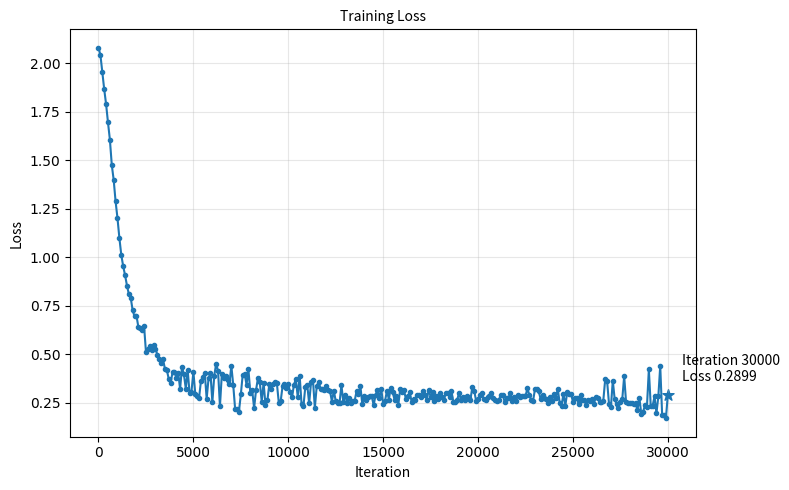

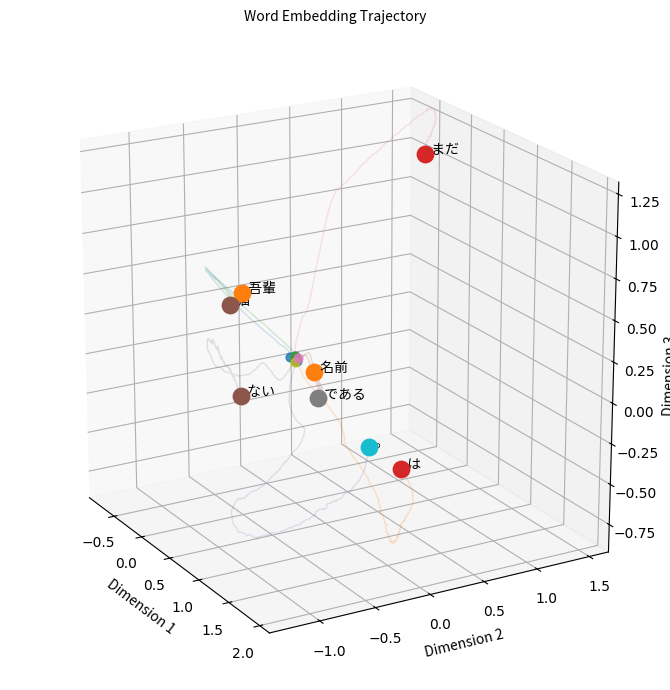

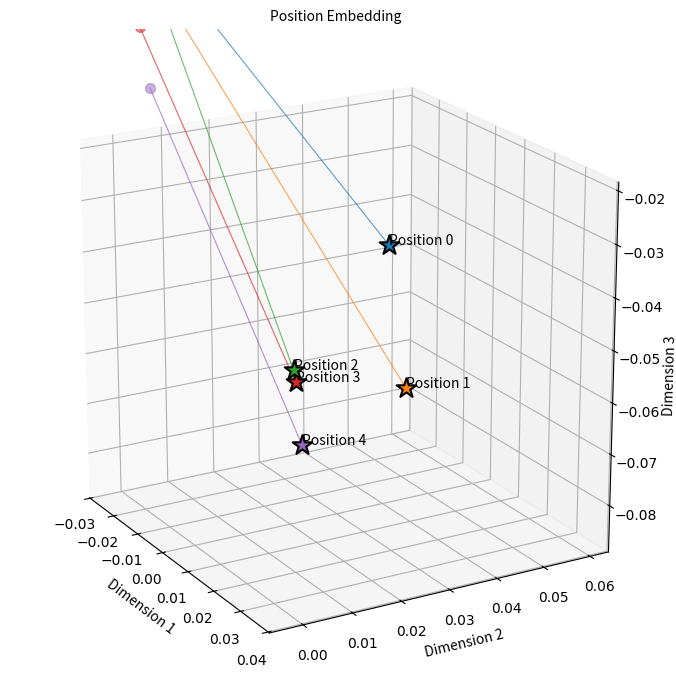

input_ids = [0 1 2]

===== LayerNorm 3D =====
吾輩 [-1.6325 -0.5804  2.0954]
は [ 1.9685 -0.1542 -1.722 ]
猫 [-0.4193 -1.665   2.0527]

x = [-1.6325  1.9685 -0.4193]
y = [-0.5804 -0.1542 -1.665 ]
z = [ 2.0954 -1.722   2.0527]


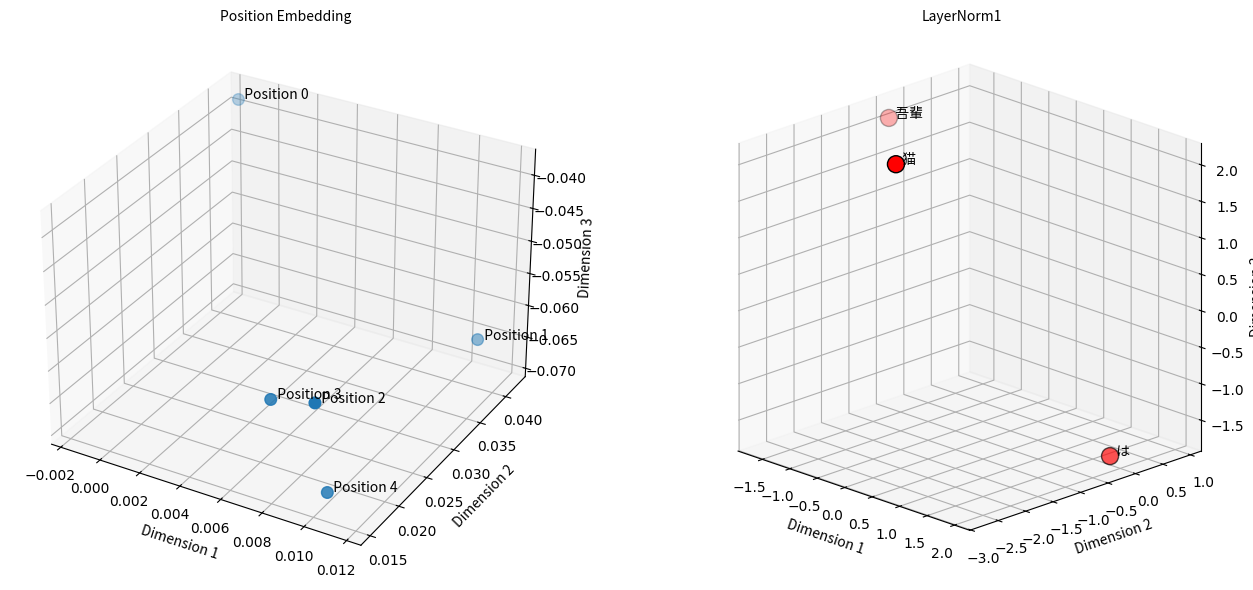

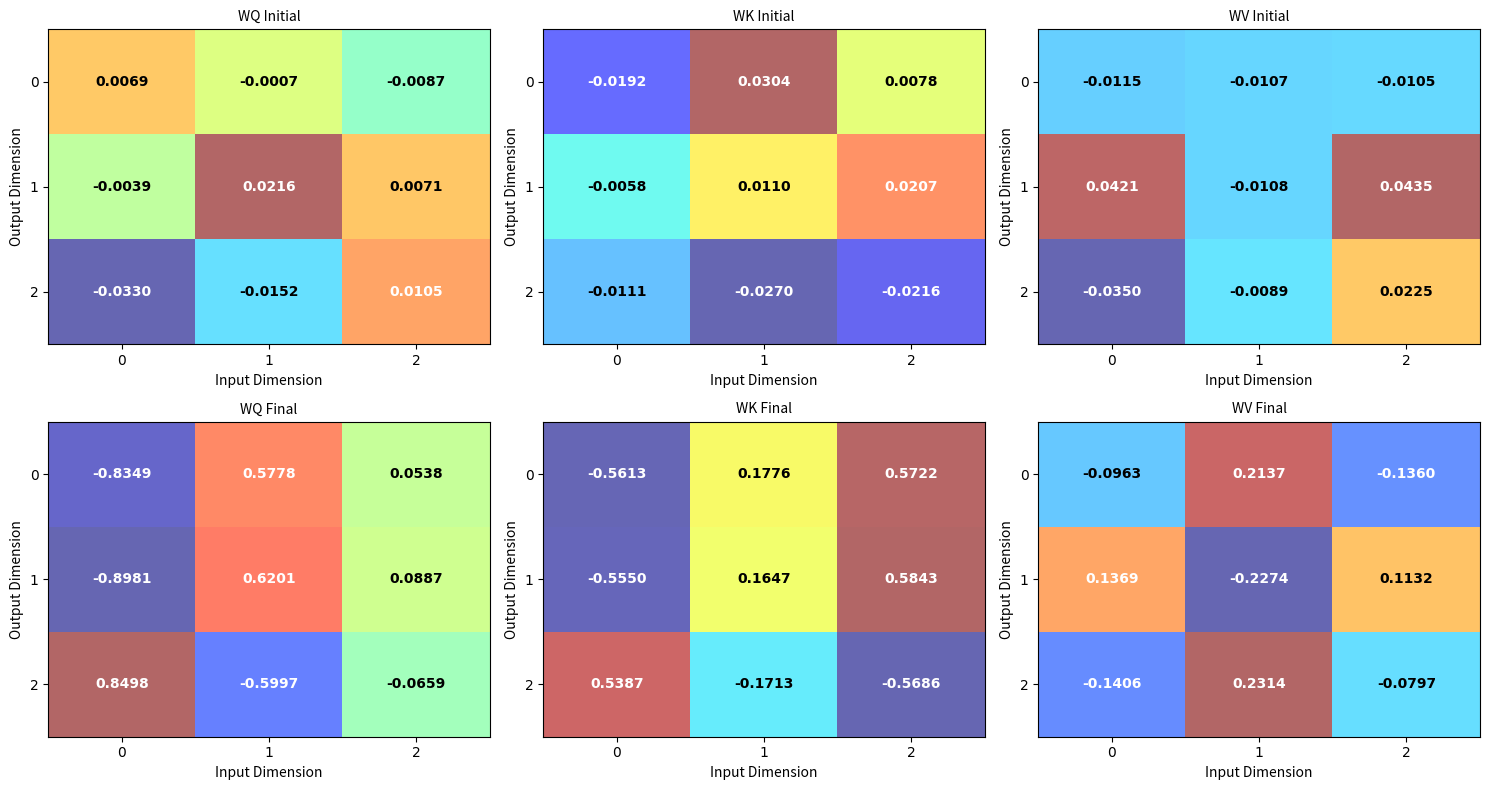

input_ids = [0 1 2]


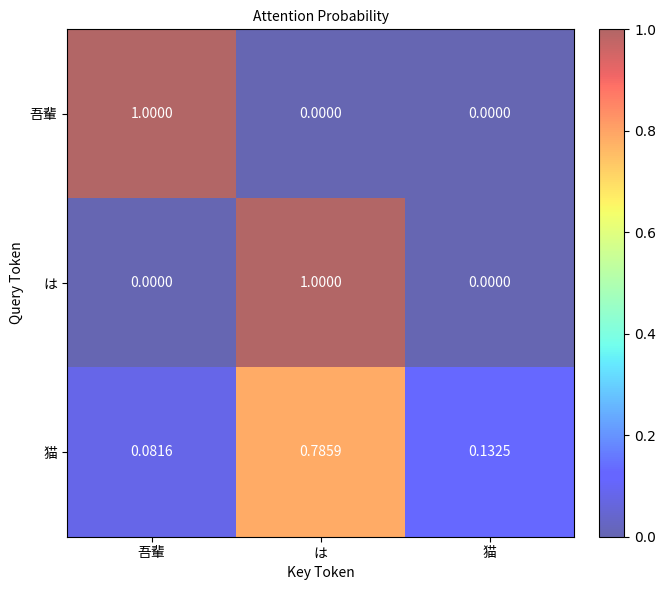

input_ids = [0 1 2]
ln2_weight = False
ln2_bias   = False
LN2_weight
[1.5243 1.4711 1.6425]
LN2_bias
[ 0.0026 -0.0127  0.0397]
ln_f_weight = False
ln_f_bias   = False
LN_F_weight
[6.1088 5.5523 6.342 ]
LN_F_bias
[-2.3941 -1.4049 -2.2462]
LM Head shape = (8, 3)
[[-0.4244 -0.2592  0.3496]
 [ 1.2345  0.2793 -0.4338]
 [-0.2168 -0.484   0.3492]
 [-0.1909  0.3238 -0.3358]
 [ 2.1006 -0.5279  0.0341]
 [-0.3712  0.3926 -0.2228]
 [-0.3017  1.4222  1.0482]
 [ 1.0554 -1.0781  0.1579]]

Recalculated Probability
[8.300e-03 0.000e+00 4.000e-04 1.000e-03 0.000e+00 1.090e-02 9.794e-01
 0.000e+00]


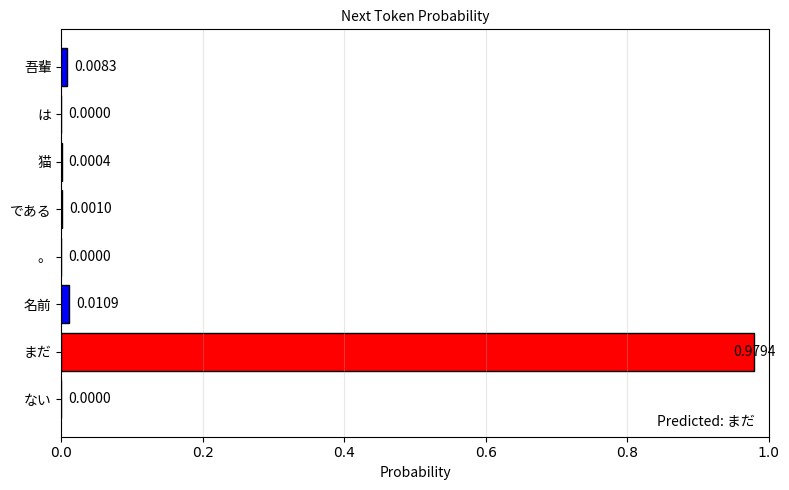

vocab = ['吾輩', 'である', '名前', 'まだ', 'ない', '猫', 'は', '。']
itos = {0: '吾輩', 1: 'である', 2: '名前', 3: 'まだ', 4: 'ない', 5: '猫', 6: 'は', 7: '。'}
tokens = ['吾輩', 'である', '名前', 'まだ', 'ない', '猫', 'は', '。']
HISTORY
directory : history
files     : 301
first     : 000000.pt
last      : 030000.pt

WORD EMBEDDING
----------------------------------------
吾輩
Initial
[-0.0423 -0.0236  0.0015]
Final
[-0.4244 -0.2592  0.3496]
----------------------------------------
である
Initial
[ 0.0131 -0.01   -0.0043]
Final
[ 1.2345  0.2793 -0.4338]
----------------------------------------
名前
Initial
[-0.0035  0.0014  0.0154]
Final
[-0.2168 -0.484   0.3492]
----------------------------------------
まだ
Initial
[0.0363 0.0065 0.0087]
Final
[-0.1909  0.3238 -0.3358]
----------------------------------------
ない
Initial
[ 0.0256 -0.0174 -0.0135]
Final
[ 2.1006 -0.5279  0.0341]
----------------------------------------
猫
Initial
[ 0.0079  0.0179 -0.015 ]
Final
[-0.3712  0.3926 -0.2228]
----------------------------------------
は
Initial

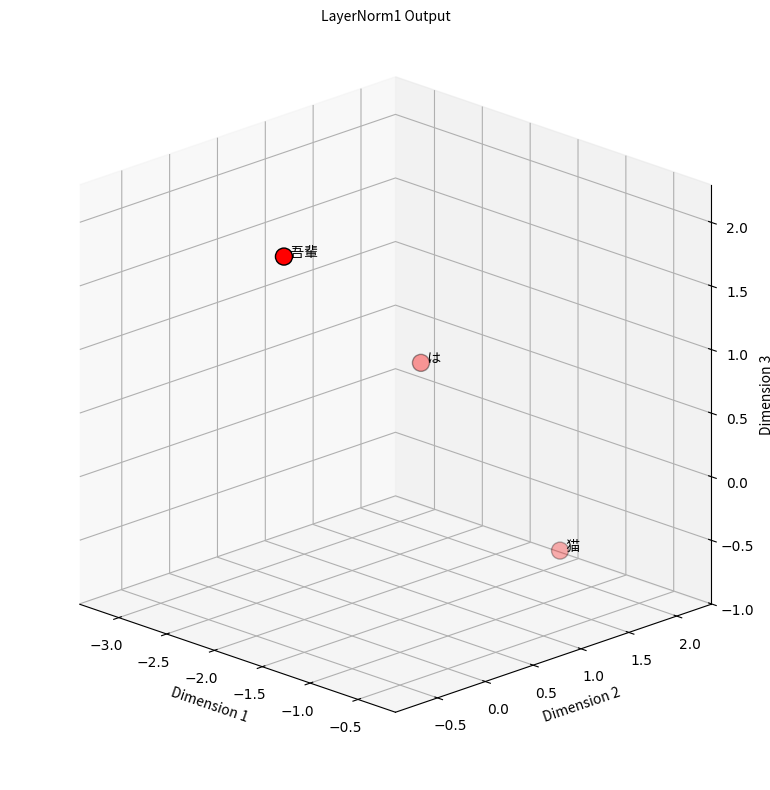

input_ids = [0 6 5]
ln2_weight = False
ln2_bias   = False
LN2_weight
[1.5243 1.4711 1.6425]
LN2_bias
[ 0.0026 -0.0127  0.0397]

===== LayerNorm 3D =====
吾輩 [-1.5367 -0.5313  2.2772]
は [-2.0905  1.4284  0.6862]
猫 [-1.1952  2.0632 -0.9874]

x = [-1.5367 -2.0905 -1.1952]
y = [-0.5313  1.4284  2.0632]
z = [ 2.2772  0.6862 -0.9874]


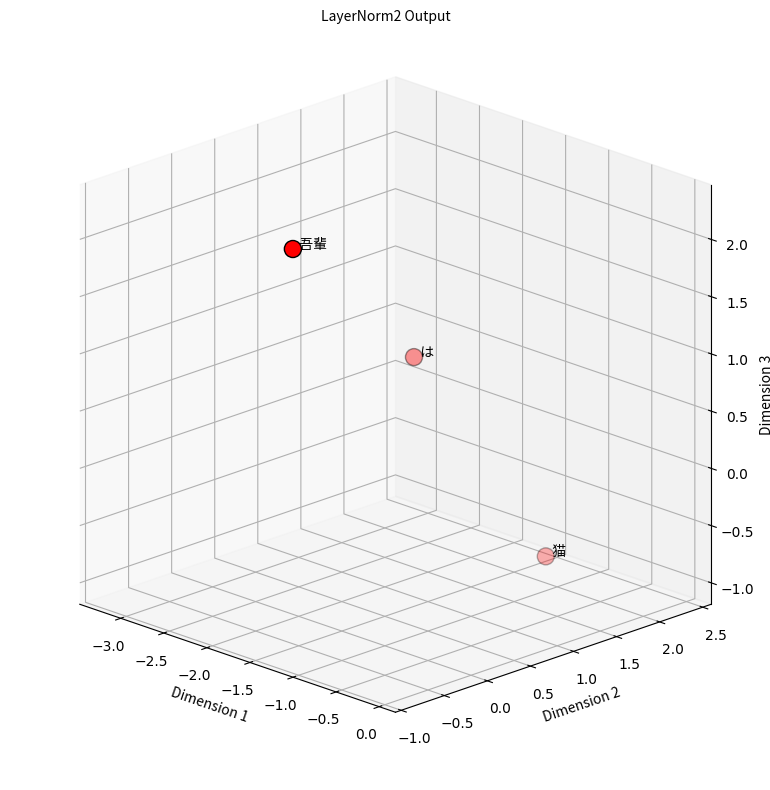


FINAL LAYER NORM
gamma
[6.1088 5.5523 6.342 ]

beta
[-2.3941 -1.4048 -2.2462]
input_ids = [0 6 5]
ln2_weight = False
ln2_bias   = False
LN2_weight
[1.5243 1.4711 1.6425]
LN2_bias
[ 0.0026 -0.0127  0.0397]
ln_f_weight = False
ln_f_bias   = False
LN_F_weight
[6.1088 5.5523 6.342 ]
LN_F_bias
[-2.3941 -1.4049 -2.2462]
LM Head shape = (8, 3)
[[-0.4244 -0.2592  0.3496]
 [ 1.2345  0.2793 -0.4338]
 [-0.2168 -0.484   0.3492]
 [-0.1909  0.3238 -0.3358]
 [ 2.1006 -0.5279  0.0341]
 [-0.3712  0.3926 -0.2228]
 [-0.3017  1.4222  1.0482]
 [ 1.0554 -1.0781  0.1579]]

Recalculated Probability
[0.     0.9772 0.     0.0131 0.0068 0.0028 0.     0.    ]

===== LayerNorm 3D =====
吾輩 [-10.9957   3.1357   1.4973]
は [-6.7292  6.4471 -6.7144]
猫 [  2.3234   2.1479 -11.2017]

x = [-10.9957  -6.7292   2.3234]
y = [3.1357 6.4471 2.1479]
z = [  1.4973  -6.7144 -11.2017]


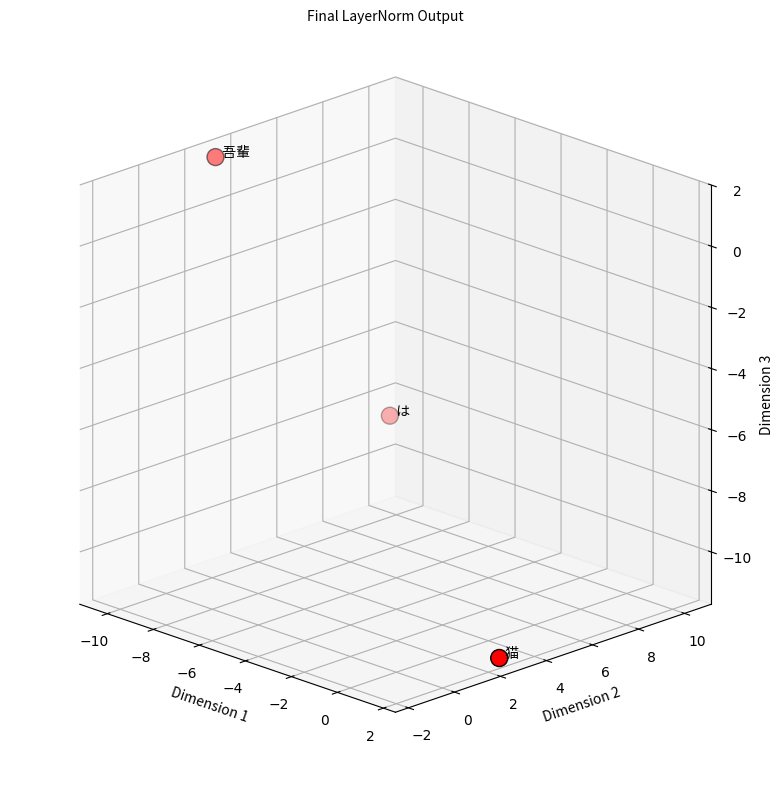

In [10]:
# ============================================================
# visualize_LLM.py
# Tiny Transformer 学習履歴の可視化
# ============================================================
import os
import glob
import time

import numpy as np
import torch

import matplotlib.pyplot as plt

from matplotlib.font_manager import FontProperties

from IPython.display import display, clear_output


# ============================================================
# 日本語フォント
# ============================================================

FONT_PATH = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

if os.path.exists(FONT_PATH):
    jpfont = FontProperties(fname=FONT_PATH)
else:
    jpfont = None
    print("日本語フォントが見つかりません。")


# ============================================================
# history 読み込み
# ============================================================

def load_history(history_dir="history"):
    """
    historyディレクトリ内の.ptファイルを
    ファイル名の数値順に読み込む。

    例
    history/00000.pt
    history/00020.pt
    history/00040.pt
    """

    files = glob.glob(
        os.path.join(history_dir, "*.pt")
    )

    if not files:
        raise FileNotFoundError(
            f"{history_dir} に .pt ファイルがありません。"
        )

    def iteration_number(path):
        name = os.path.splitext(
            os.path.basename(path)
        )[0]

        try:
            return int(name)
        except ValueError:
            return float("inf")

    files = sorted(
        files,
        key=iteration_number
    )


    history = []

    for path in files:
        data = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

        history.append(data)

    print("============================================================")
    print("HISTORY")
    print("============================================================")
    print("directory :", history_dir)
    print("files     :", len(files))
    print("first     :", os.path.basename(files[0]))
    print("last      :", os.path.basename(files[-1]))
    return history
# ============================================================
# 共通変換関数
# ============================================================

def to_numpy(x):
    """
    TensorまたはNumPy配列をNumPy配列に変換する。
    """

    if torch.is_tensor(x):
        return x.detach().cpu().numpy()

    return np.asarray(x)


def remove_batch_dimension(x):
    """
    先頭に余分なバッチ次元がある場合に取り除く。

    例
    [1, 3, 3] → [3, 3]
    [1, 1, 3, 3] → [3, 3]
    """

    x = to_numpy(x)

    while x.ndim > 2 and x.shape[0] == 1:
        x = x[0]

    return x


def to_vector(x):
    """
    Tensorまたは配列を1次元ベクトルに変換する。

    例
    [1, 1, 8] → [8]
    [1, 8]    → [8]
    """

    x = to_numpy(x)

    while x.ndim > 1:
        x = x[0]

    return x


def get_history_value(state, key):
    """
    historyの1ステップから指定キーの値を取得する。
    キーが存在しない場合はエラーを出す。
    """

    if key not in state:
        available_keys = "\n".join(
            f"  {k}" for k in state.keys()
        )

        raise KeyError(
            f"historyに '{key}' がありません。\n"
            f"保存されているキー:\n{available_keys}"
        )

    return state[key]


def get_iteration(state, default_value=0):
    """
    historyの1ステップからiteration番号を取得する。
    """

    if "iter" in state:
        value = state["iter"]

    elif "iteration" in state:
        value = state["iteration"]

    elif "step" in state:
        value = state["step"]

    else:
        return default_value

    if torch.is_tensor(value):
        value = value.item()

    return int(value)

    # ============================================================
# トークン名取得
# ============================================================

def make_token_list(vocab=None, itos=None):
    """
    vocab または itos から、ID順のトークン一覧を作る。

    対応例
    vocab = ["吾輩", "は", "猫"]
    itos  = {0:"吾輩", 1:"は", 2:"猫"}
    """

    if itos is not None:
        if isinstance(itos, dict):
            token_ids = sorted(itos.keys())
            return [itos[i] for i in token_ids]

        if isinstance(itos, (list, tuple)):
            return list(itos)

    if vocab is not None:
        if isinstance(vocab, dict):
            if all(isinstance(k, int) for k in vocab.keys()):
                token_ids = sorted(vocab.keys())
                return [vocab[i] for i in token_ids]

            if all(isinstance(v, int) for v in vocab.values()):
                return [
                    token
                    for token, token_id
                    in sorted(vocab.items(), key=lambda x: x[1])
                ]

        if isinstance(vocab, (list, tuple)):
            return list(vocab)

    raise ValueError(
        "vocab または itos を指定してください。"
    )


def get_token_name(token_id, vocab=None, itos=None):
    """
    トークンIDからトークン文字列を取得する。
    """

    tokens = make_token_list(
        vocab=vocab,
        itos=itos
    )

    token_id = int(token_id)

    if token_id < 0 or token_id >= len(tokens):
        return f"<ID:{token_id}>"

    return tokens[token_id]


def get_token_names(token_ids, vocab=None, itos=None):
    """
    複数のトークンIDをトークン文字列へ変換する。
    """

    token_ids = to_numpy(token_ids).reshape(-1)

    return [
        get_token_name(
            token_id,
            vocab=vocab,
            itos=itos
        )
        for token_id in token_ids
    ]
    
# ============================================================
# Embedding表示
# ============================================================

def print_embeddings(history, vocab=None, itos=None):
    """
    Word Embedding と Position Embedding の
    初期値・最終値を表示する。
    """

    first = history[0]
    last = history[-1]

    tokens = make_token_list(
        vocab=vocab,
        itos=itos
    )

    # --------------------------------------------------------
    # Word Embedding
    # --------------------------------------------------------

    print()
    print("============================================================")
    print("WORD EMBEDDING")
    print("============================================================")

    emb0 = to_numpy(
        get_history_value(
            first,
            "embedding_weight"
        )
    )

    emb1 = to_numpy(
        get_history_value(
            last,
            "embedding_weight"
        )
    )

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(token)

        print("Initial")
        print(np.round(emb0[i], 4))

        print("Final")
        print(np.round(emb1[i], 4))

    # --------------------------------------------------------
    # Position Embedding
    # --------------------------------------------------------

    if (
        "position_weight" not in first
        or
        "position_weight" not in last
    ):
        return

    print()
    print("============================================================")
    print("POSITION EMBEDDING")
    print("============================================================")

    pos0 = to_numpy(
        first["position_weight"]
    )

    pos1 = to_numpy(
        last["position_weight"]
    )

    for p in range(len(pos0)):

        print("----------------------------------------")
        print(f"Position {p}")

        print("Initial")
        print(np.round(pos0[p], 4))

        print("Final")
        print(np.round(pos1[p], 4))

# ============================================================
# LayerNorm Parameters
# ============================================================

def print_layernorm_parameters(history):
    """
    LayerNorm の γ(weight) と β(bias) の
    初期値・最終値を表示する。
    """

    first = history[0]
    last  = history[-1]

    targets = [
        (
            "LayerNorm1",
            [
                "LN1_weight",
                "ln1_weight",
                "ln_1_weight",
                "transformer.h.0.ln_1.weight"
            ],
            [
                "LN1_bias",
                "ln1_bias",
                "ln_1_bias",
                "transformer.h.0.ln_1.bias"
            ]
        ),
        (
            "LayerNorm2",
            [
                "LN2_weight",
                "ln2_weight",
                "ln_2_weight",
                "transformer.h.0.ln_2.weight"
            ],
            [
                "LN2_bias",
                "ln2_bias",
                "ln_2_bias",
                "transformer.h.0.ln_2.bias"
            ]
        ),
        (
            "Final LayerNorm",
            [
                "LN_F_weight",
                "ln_f_weight",
                "transformer.ln_f.weight"
            ],
            [
                "LN_F_bias",
                "ln_f_bias",
                "transformer.ln_f.bias"
            ]
        )
    ]

    print()
    print("============================================================")
    print("LAYERNORM PARAMETERS")
    print("============================================================")

    for name, weight_keys, bias_keys in targets:

        w0 = find_history_value(first, weight_keys, required=False)
        w1 = find_history_value(last , weight_keys, required=False)

        b0 = find_history_value(first, bias_keys, required=False)
        b1 = find_history_value(last , bias_keys, required=False)

        if w0 is None:
            continue

        print()
        print("------------------------------------------------------------")
        print(name)
        print("------------------------------------------------------------")

        print("Gamma (weight)")
        print("Initial")
        print(np.round(to_numpy(w0),4))
        print("Final")
        print(np.round(to_numpy(w1),4))

        if b0 is not None:
            print()
            print("Beta (bias)")
            print("Initial")
            print(np.round(to_numpy(b0),4))
            print("Final")
            print(np.round(to_numpy(b1),4))
# ============================================================
# Transformer Input
# ============================================================

def print_transformer_input(
    history,
    input_ids,
    vocab=None,
    itos=None
):
    """
    Transformerへの入力
        Word Embedding
      + Position Embedding
    を表示する。
    """

    state = history[-1]
    print()
    print("========== HISTORY KEYS ==========")

    for k in sorted(state.keys()):
        print(k)

    word_embedding = to_numpy(
        get_history_value(
            state,
            "embedding_weight"
        )
    )

    position_embedding = to_numpy(
        get_history_value(
            state,
            "position_weight"
        )
    )

    input_ids = to_numpy(input_ids).reshape(-1)

    print()
    print("============================================================")
    print("TRANSFORMER INPUT")
    print("============================================================")

    for pos, token_id in enumerate(input_ids):

        token = get_token_name(
            token_id,
            vocab=vocab,
            itos=itos
        )

        w = word_embedding[token_id]
        p = position_embedding[pos]
        x = w + p

        print("----------------------------------------")
        print(f"Position {pos}")
        print("Token")
        print(token)

        print()

        print("Word Embedding")
        print(np.round(w, 4))

        print()

        print("Position Embedding")
        print(np.round(p, 4))

        print()

        print("Transformer Input")
        print(np.round(x, 4))

# ============================================================
# WQ / WK / WV の取得
# ============================================================

def split_qkv_weight(c_attn_weight):
    """
    c_attn.weight を WQ、WK、WV に分割する。

    nanoGPT の c_attn.weight の形状は通常、

        [3 * n_embd, n_embd]

    なので、行方向 axis=0 で3分割する。
    """

    weight = to_numpy(c_attn_weight)

    if weight.ndim != 2:
        raise ValueError(
            "c_attn_weight は2次元行列である必要があります。\n"
            f"実際のshape: {weight.shape}"
        )

    if weight.shape[0] % 3 != 0:
        raise ValueError(
            "c_attn_weight の行数が3で割り切れません。\n"
            f"実際のshape: {weight.shape}"
        )

    n_embd = weight.shape[0] // 3

    WQ = weight[0:n_embd, :]
    WK = weight[n_embd:2 * n_embd, :]
    WV = weight[2 * n_embd:3 * n_embd, :]

    return WQ, WK, WV


# ============================================================
# BQ / BK / BV の取得
# ============================================================

def split_qkv_bias(c_attn_bias):
    """
    c_attn.bias を BQ、BK、BV に分割する。

    c_attn.bias が存在しない場合は、
    Noneを3つ返す。
    """

    if c_attn_bias is None:
        return None, None, None

    bias = to_numpy(c_attn_bias).reshape(-1)

    if len(bias) % 3 != 0:
        raise ValueError(
            "c_attn_bias の要素数が3で割り切れません。\n"
            f"実際のshape: {bias.shape}"
        )

    n_embd = len(bias) // 3

    BQ = bias[0:n_embd]
    BK = bias[n_embd:2 * n_embd]
    BV = bias[2 * n_embd:3 * n_embd]

    return BQ, BK, BV


# ============================================================
# WQ / WK / WV 表示
# ============================================================

# ============================================================
# WQ / WK / WV 表示
# ============================================================

def print_WQ_WK_WV(history):
    """
    WQ、WK、WVの初期値と最終値を表示する。

    historyにWQ、WK、WVが直接保存されている場合と、
    c_attn.weightとして保存されている場合の両方に対応する。
    """

    first = history[0]
    last = history[-1]

    # --------------------------------------------------------
    # WQ / WK / WV が直接保存されている場合
    # --------------------------------------------------------

    if all(
        key in first and key in last
        for key in ["WQ", "WK", "WV"]
    ):

        WQ_initial = to_numpy(first["WQ"])
        WK_initial = to_numpy(first["WK"])
        WV_initial = to_numpy(first["WV"])

        WQ_final = to_numpy(last["WQ"])
        WK_final = to_numpy(last["WK"])
        WV_final = to_numpy(last["WV"])

    # --------------------------------------------------------
    # c_attn.weightとして保存されている場合
    # --------------------------------------------------------

    else:

        possible_keys = [
            "c_attn_weight",
            "attn_c_attn_weight",
            "transformer.h.0.attn.c_attn.weight"
        ]

        weight_key = None

        for key in possible_keys:
            if key in first and key in last:
                weight_key = key
                break

        if weight_key is None:
            raise KeyError(
                "WQ/WK/WVまたはc_attn.weightが"
                "historyに保存されていません。\n\n"
                "実際のキー:\n"
                + "\n".join(
                    f"  {key}"
                    for key in first.keys()
                )
            )

        WQ_initial, WK_initial, WV_initial = split_qkv_weight(
            first[weight_key]
        )

        WQ_final, WK_final, WV_final = split_qkv_weight(
            last[weight_key]
        )

    # --------------------------------------------------------
    # 表示
    # --------------------------------------------------------

    print()
    print("============================================================")
    print("WQ")
    print("============================================================")

    print("Initial")
    print(np.round(WQ_initial, 4))

    print()
    print("Final")
    print(np.round(WQ_final, 4))

    print()
    print("============================================================")
    print("WK")
    print("============================================================")

    print("Initial")
    print(np.round(WK_initial, 4))

    print()
    print("Final")
    print(np.round(WK_final, 4))

    print()
    print("============================================================")
    print("WV")
    print("============================================================")

    print("Initial")
    print(np.round(WV_initial, 4))

    print()
    print("Final")
    print(np.round(WV_final, 4))
# ============================================================
# Layer Normalization
# ============================================================

def layer_norm_numpy(
    x,
    weight=None,
    bias=None,
    eps=1e-5
):
    """
    PyTorchのLayerNormと同じ計算をNumPyで行う。

    x:
        [sequence_length, n_embd]
    """

    x = to_numpy(x)

    mean = np.mean(
        x,
        axis=-1,
        keepdims=True
    )

    variance = np.var(
        x,
        axis=-1,
        keepdims=True
    )

    y = (
        x - mean
    ) / np.sqrt(
        variance + eps
    )

    if weight is not None:
        y = y * to_numpy(weight)

    if bias is not None:
        y = y + to_numpy(bias)

    return y


# ============================================================
# historyから候補キーを探す
# ============================================================

def find_history_value(
    state,
    candidate_keys,
    required=True
):
    """
    candidate_keysの上から順に、
    history内に存在する値を返す。
    """

    for key in candidate_keys:
        if key in state:
            return state[key]

    if required:
        raise KeyError(
            "history内に必要なキーがありません。\n"
            "候補キー:\n"
            + "\n".join(
                f"  {key}"
                for key in candidate_keys
            )
            + "\n\n実際のキー:\n"
            + "\n".join(
                f"  {key}"
                for key in state.keys()
            )
        )

    return None


# ============================================================
# Q / K / V の計算
# ============================================================

def calculate_Q_K_V(
    history,
    input_ids,
    use_layer_norm=True
):
    """
    最終学習状態のパラメータを使って、
    入力トークン列からQ、K、Vを計算する。
    """

    state = history[-1]

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)
    print("input_ids =", input_ids)
    # --------------------------------------------------------
    # Word Embedding
    # --------------------------------------------------------

    embedding_weight = to_numpy(
        find_history_value(
            state,
            [
                "embedding_weight",
                "transformer.wte.weight"
            ]
        )
    )

    # --------------------------------------------------------
    # Position Embedding
    # --------------------------------------------------------

    position_weight = to_numpy(
        find_history_value(
            state,
            [
                "position_weight",
                "transformer.wpe.weight"
            ]
        )
    )

    sequence_length = len(input_ids)

    if sequence_length > len(position_weight):
        raise ValueError(
            "入力系列がPosition Embeddingの長さを超えています。\n"
            f"入力長: {sequence_length}\n"
            f"Position数: {len(position_weight)}"
        )

    word_embedding = embedding_weight[
        input_ids
    ]

    position_embedding = position_weight[
        :sequence_length
    ]

    transformer_input = (
        word_embedding
        +
        position_embedding
    )

    # --------------------------------------------------------
    # LayerNorm
    # --------------------------------------------------------

    attention_input = transformer_input.copy()

    if use_layer_norm:

        ln1_weight = find_history_value(
            state,
            [
                "LN1_weight",
                "ln1_weight",
                "ln_1_weight",
                "transformer.h.0.ln_1.weight"
            ],
            required=False
        )

        ln1_bias = find_history_value(
            state,
            [
                "LN1_bias",
                "ln1_bias",
                "ln_1_bias",
                "transformer.h.0.ln_1.bias"
            ],
            required=False
        )

        if ln1_weight is not None:
            attention_input = layer_norm_numpy(
                transformer_input,
                weight=ln1_weight,
                bias=ln1_bias
            )

    # --------------------------------------------------------
    # WQ / WK / WV
    # --------------------------------------------------------

    if all(
        key in state
        for key in ["WQ", "WK", "WV"]
    ):

        WQ = to_numpy(
            state["WQ"]
        )

        WK = to_numpy(
            state["WK"]
        )

        WV = to_numpy(
            state["WV"]
        )

    else:

        c_attn_weight = find_history_value(
            state,
            [
                "c_attn_weight",
                "attn_c_attn_weight",
                "transformer.h.0.attn.c_attn.weight"
            ]
        )

        WQ, WK, WV = split_qkv_weight(
            c_attn_weight
        )

    # --------------------------------------------------------
    # WQ / WK / WV bias
    # --------------------------------------------------------

    if all(
        key in state
        for key in [
            "WQ_bias",
            "WK_bias",
            "WV_bias"
        ]
    ):

        BQ = to_numpy(
            state["WQ_bias"]
        ).reshape(-1)

        BK = to_numpy(
            state["WK_bias"]
        ).reshape(-1)

        BV = to_numpy(
            state["WV_bias"]
        ).reshape(-1)

    else:

        c_attn_bias = find_history_value(
            state,
            [
                "c_attn_bias",
                "attn_c_attn_bias",
                "transformer.h.0.attn.c_attn.bias"
            ],
            required=False
        )

        BQ, BK, BV = split_qkv_bias(
            c_attn_bias
        )

    # --------------------------------------------------------
    # PyTorch Linear
    # output = input @ weight.T + bias
    # --------------------------------------------------------

    Q = attention_input @ WQ.T
    K = attention_input @ WK.T
    V = attention_input @ WV.T

    if BQ is not None:
        Q = Q + BQ

    if BK is not None:
        K = K + BK

    if BV is not None:
        V = V + BV

    return {
        "word_embedding": word_embedding,
        "position_embedding": position_embedding,
        "transformer_input": transformer_input,
        "attention_input": attention_input,
        "WQ": WQ,
        "WK": WK,
        "WV": WV,
        "BQ": BQ,
        "BK": BK,
        "BV": BV,
        "Q": Q,
        "K": K,
        "V": V
    }
# ============================================================
# Q / K / V の表示
# ============================================================

def print_Q_K_V(
    history,
    input_ids,
    vocab=None,
    itos=None,
    use_layer_norm=True
):
    """
    最終学習状態のWQ、WK、WVを使って、
    各入力トークンのQ、K、Vを表示する。
    """

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)

    result = calculate_Q_K_V(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    Q = result["Q"]
    K = result["K"]
    V = result["V"]

    print()
    print("============================================================")
    print("Q / K / V")
    print("============================================================")

    for position, token_id in enumerate(input_ids):

        token = get_token_name(
            token_id,
            vocab=vocab,
            itos=itos
        )

        print("----------------------------------------")
        print(token)
        print(f"Position {position}")

        print()
        print("Q")
        print(np.round(Q[position], 4))

        print()
        print("K")
        print(np.round(K[position], 4))

        print()
        print("V")
        print(np.round(V[position], 4))

# ============================================================
# Softmax
# ============================================================

def softmax_numpy(x, axis=-1):
    """
    数値的に安定したSoftmaxをNumPyで計算する。
    """

    x = to_numpy(x)

    x_max = np.max(
        x,
        axis=axis,
        keepdims=True
    )

    exp_x = np.exp(
        x - x_max
    )

    return exp_x / np.sum(
        exp_x,
        axis=axis,
        keepdims=True
    )


# ============================================================
# Attention計算
# ============================================================

def calculate_attention(
    history,
    input_ids,
    use_layer_norm=True
):
    """
    Q、K、VからSelf-Attentionを計算する。

    計算順序:

        Attention Score
            = Q @ K.T / sqrt(d_k)

        Causal Mask適用

        Attention Probability
            = Softmax(Masked Score)

        Attention Output
            = Attention Probability @ V

    1層・1ヘッドの教材用モデルを想定している。
    """

    qkv_result = calculate_Q_K_V(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    Q = qkv_result["Q"]
    K = qkv_result["K"]
    V = qkv_result["V"]

    if Q.ndim != 2:
        raise ValueError(
            "Qは2次元行列である必要があります。\n"
            f"Q shape: {Q.shape}"
        )

    if K.ndim != 2:
        raise ValueError(
            "Kは2次元行列である必要があります。\n"
            f"K shape: {K.shape}"
        )

    if V.ndim != 2:
        raise ValueError(
            "Vは2次元行列である必要があります。\n"
            f"V shape: {V.shape}"
        )

    sequence_length = Q.shape[0]
    d_k = Q.shape[-1]

    # --------------------------------------------------------
    # Attention Score
    # --------------------------------------------------------

    attention_score = (
        Q @ K.T
    ) / np.sqrt(d_k)

    # --------------------------------------------------------
    # Causal Mask
    #
    # 未来のトークンを参照できないように、
    # 上三角部分を -inf にする。
    # --------------------------------------------------------

    causal_mask = np.triu(
        np.ones(
            (
                sequence_length,
                sequence_length
            ),
            dtype=bool
        ),
        k=1
    )

    masked_score = attention_score.copy()

    masked_score[
        causal_mask
    ] = -np.inf

    # --------------------------------------------------------
    # Softmax
    # --------------------------------------------------------

    attention_probability = softmax_numpy(
        masked_score,
        axis=-1
    )

    # --------------------------------------------------------
    # Attention Output
    # --------------------------------------------------------

    attention_output = (
        attention_probability @ V
    )

    result = dict(qkv_result)

    result.update(
        {
            "attention_score": attention_score,
            "causal_mask": causal_mask,
            "masked_score": masked_score,
            "attention_probability": attention_probability,
            "attention_output": attention_output
        }
    )

    return result


# ============================================================
# 行列表示用
# ============================================================

def print_matrix_with_labels(
    matrix,
    row_labels,
    column_labels,
    decimals=4
):
    """
    行ラベル・列ラベル付きで行列を表示する。
    """

    matrix = to_numpy(matrix)

    label_width = max(
        10,
        max(
            len(str(label))
            for label in row_labels + column_labels
        ) + 2
    )

    value_width = 10

    print(
        " " * label_width,
        end=""
    )

    for label in column_labels:
        print(
            f"{str(label):>{value_width}}",
            end=""
        )

    print()

    for i, row_label in enumerate(row_labels):

        print(
            f"{str(row_label):<{label_width}}",
            end=""
        )

        for value in matrix[i]:

            if np.isneginf(value):
                text = "-inf"
            elif np.isposinf(value):
                text = "inf"
            elif np.isnan(value):
                text = "nan"
            else:
                text = f"{value:.{decimals}f}"

            print(
                f"{text:>{value_width}}",
                end=""
            )

        print()


# ============================================================
# Attention表示
# ============================================================

def print_attention(
    history,
    input_ids,
    vocab=None,
    itos=None,
    use_layer_norm=True
):
    """
    Attention Score、Masked Score、
    Softmax確率、Attention Outputを表示する。
    """

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)

    token_names = get_token_names(
        input_ids,
        vocab=vocab,
        itos=itos
    )

    result = calculate_attention(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    attention_score = result[
        "attention_score"
    ]

    masked_score = result[
        "masked_score"
    ]

    attention_probability = result[
        "attention_probability"
    ]

    attention_output = result[
        "attention_output"
    ]

    # --------------------------------------------------------
    # Attention Score
    # --------------------------------------------------------

    print()
    print("============================================================")
    print("ATTENTION SCORE")
    print("Q @ K.T / sqrt(d_k)")
    print("============================================================")

    print_matrix_with_labels(
        attention_score,
        row_labels=token_names,
        column_labels=token_names
    )

    # --------------------------------------------------------
    # Masked Attention Score
    # --------------------------------------------------------

    print()
    print("============================================================")
    print("MASKED ATTENTION SCORE")
    print("============================================================")

    print_matrix_with_labels(
        masked_score,
        row_labels=token_names,
        column_labels=token_names
    )

    # --------------------------------------------------------
    # Attention Probability
    # --------------------------------------------------------

    print()
    print("============================================================")
    print("ATTENTION PROBABILITY")
    print("Softmax")
    print("============================================================")

    print_matrix_with_labels(
        attention_probability,
        row_labels=token_names,
        column_labels=token_names
    )

    # --------------------------------------------------------
    # Attention Output
    # --------------------------------------------------------

    print()
    print("============================================================")
    print("ATTENTION OUTPUT")
    print("Attention Probability @ V")
    print("============================================================")

    for position, token in enumerate(token_names):

        print("----------------------------------------")
        print(token)
        print(f"Position {position}")

        print(
            np.round(
                attention_output[position],
                4
            )
        )

# ============================================================
# Attention Projection + Residual Connection
# ============================================================

# ============================================================
# Attention Projection + Residual Connection
# ============================================================

def calculate_attention_residual(
    history,
    input_ids,
    use_layer_norm=True
):
    """
    Attention出力に出力射影WOを適用し、
    Transformer入力との残差接続まで計算する。

    historyに保存されている

        WO
        WO_bias

    を使用する。
    """

    state = history[-1]

    result = calculate_attention(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    transformer_input = result[
        "transformer_input"
    ]

    attention_output = result[
        "attention_output"
    ]

    # --------------------------------------------------------
    # Attention出力射影行列
    # --------------------------------------------------------

    c_proj_weight = find_history_value(
        state,
        [
            "WO",
            "attn_c_proj_weight",
            "c_proj_weight",
            "transformer.h.0.attn.c_proj.weight"
        ]
    )

    c_proj_weight = to_numpy(
        c_proj_weight
    )

    # --------------------------------------------------------
    # Attention出力射影バイアス
    # --------------------------------------------------------

    c_proj_bias = find_history_value(
        state,
        [
            "WO_bias",
            "attn_c_proj_bias",
            "c_proj_bias",
            "transformer.h.0.attn.c_proj.bias"
        ],
        required=False
    )

    if c_proj_bias is not None:
        c_proj_bias = to_numpy(
            c_proj_bias
        ).reshape(-1)

    # --------------------------------------------------------
    # PyTorch Linear
    # output = input @ weight.T + bias
    # --------------------------------------------------------

    projected_attention = (
        attention_output @ c_proj_weight.T
    )

    if c_proj_bias is not None:
        projected_attention = (
            projected_attention
            +
            c_proj_bias
        )

    # --------------------------------------------------------
    # Residual Connection
    # --------------------------------------------------------

    residual_output = (
        transformer_input
        +
        projected_attention
    )

    result.update(
        {
            "attn_c_proj_weight": c_proj_weight,
            "attn_c_proj_bias": c_proj_bias,
            "projected_attention": projected_attention,
            "attention_residual_output": residual_output
        }
    )

    return result
# ============================================================
# Attention Projection + Residual表示
# ============================================================

def print_attention_residual(
    history,
    input_ids,
    vocab=None,
    itos=None,
    use_layer_norm=True
):
    """
    Attention出力、c_proj後の値、
    残差接続後の値を表示する。
    """

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)

    token_names = get_token_names(
        input_ids,
        vocab=vocab,
        itos=itos
    )

    result = calculate_attention_residual(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    attention_output = result[
        "attention_output"
    ]

    projected_attention = result[
        "projected_attention"
    ]

    transformer_input = result[
        "transformer_input"
    ]

    residual_output = result[
        "attention_residual_output"
    ]

    print()
    print("============================================================")
    print("ATTENTION PROJECTION / RESIDUAL")
    print("============================================================")

    for position, token in enumerate(token_names):

        print("----------------------------------------")
        print(token)
        print(f"Position {position}")

        print()
        print("Attention Output")
        print(
            np.round(
                attention_output[position],
                4
            )
        )

        print()
        print("After c_proj")
        print(
            np.round(
                projected_attention[position],
                4
            )
        )

        print()
        print("Residual Input")
        print(
            np.round(
                transformer_input[position],
                4
            )
        )

        print()
        print("Residual Output")
        print(
            np.round(
                residual_output[position],
                4
            )
        )
# ============================================================
# GELU
# ============================================================

def gelu_numpy(x):
    """
    nanoGPTで使われるGELUをNumPyで計算する。

    PyTorchのGELU近似:
        approximate="tanh"
    """

    x = to_numpy(x)

    return 0.5 * x * (
        1.0
        +
        np.tanh(
            np.sqrt(2.0 / np.pi)
            *
            (
                x
                +
                0.044715 * x ** 3
            )
        )
    )


# ============================================================
# MLP + Residual Connection
# ============================================================

def calculate_mlp_residual(
    history,
    input_ids,
    use_layer_norm=True
):
    """
    Attention残差出力から、

        ln_2
        → FFN1
        → GELU
        → FFN2
        → 2回目の残差接続

    までを計算する。
    """

    state = history[-1]

    result = calculate_attention_residual(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    attention_residual_output = result[
        "attention_residual_output"
    ]

    # --------------------------------------------------------
    # ln_2
    # --------------------------------------------------------

    mlp_input = attention_residual_output.copy()

    if use_layer_norm:

        ln2_weight = find_history_value(
            state,
            [
                "LN2_weight",
                "ln2_weight",
                "ln_2_weight",
                "transformer.h.0.ln_2.weight"
            ],
            required=False
        )

        ln2_bias = find_history_value(
            state,
            [
                "LN2_bias",
                "ln2_bias",
                "ln_2_bias",
                "transformer.h.0.ln_2.bias"
            ],
            required=False
        )
###################################
        print("ln2_weight =", ln2_weight is None)
        print("ln2_bias   =", ln2_bias is None)

        if ln2_weight is not None:
            print("LN2_weight")
            print(np.round(to_numpy(ln2_weight), 4))

        if ln2_bias is not None:
            print("LN2_bias")
            print(np.round(to_numpy(ln2_bias), 4))

####################################
        if ln2_weight is not None:
            mlp_input = layer_norm_numpy(
                attention_residual_output,
                weight=ln2_weight,
                bias=ln2_bias
            )

    # --------------------------------------------------------
    # FFN1
    # --------------------------------------------------------

    c_fc_weight = to_numpy(
        find_history_value(
            state,
            [
                "FFN1",
                "mlp_c_fc_weight",
                "transformer.h.0.mlp.c_fc.weight"
            ]
        )
    )

    c_fc_bias = find_history_value(
        state,
        [
            "FFN1_bias",
            "mlp_c_fc_bias",
            "transformer.h.0.mlp.c_fc.bias"
        ],
        required=False
    )

    if c_fc_bias is not None:
        c_fc_bias = to_numpy(
            c_fc_bias
        ).reshape(-1)

    mlp_hidden = (
        mlp_input @ c_fc_weight.T
    )

    if c_fc_bias is not None:
        mlp_hidden = (
            mlp_hidden + c_fc_bias
        )

    # --------------------------------------------------------
    # GELU
    # --------------------------------------------------------

    mlp_activated = gelu_numpy(
        mlp_hidden
    )

    # --------------------------------------------------------
    # FFN2
    # --------------------------------------------------------

    mlp_c_proj_weight = to_numpy(
        find_history_value(
            state,
            [
                "FFN2",
                "mlp_c_proj_weight",
                "transformer.h.0.mlp.c_proj.weight"
            ]
        )
    )

    mlp_c_proj_bias = find_history_value(
        state,
        [
            "FFN2_bias",
            "mlp_c_proj_bias",
            "transformer.h.0.mlp.c_proj.bias"
        ],
        required=False
    )

    if mlp_c_proj_bias is not None:
        mlp_c_proj_bias = to_numpy(
            mlp_c_proj_bias
        ).reshape(-1)

    mlp_output = (
        mlp_activated
        @
        mlp_c_proj_weight.T
    )

    if mlp_c_proj_bias is not None:
        mlp_output = (
            mlp_output
            +
            mlp_c_proj_bias
        )

    # --------------------------------------------------------
    # 2回目の残差接続
    # --------------------------------------------------------

    block_output = (
        attention_residual_output
        +
        mlp_output
    )

    result.update(
        {
            "ln2_output": mlp_input,
            "mlp_hidden": mlp_hidden,
            "mlp_activated": mlp_activated,
            "mlp_output": mlp_output,
            "block_output": block_output
        }
    )

    return result
# ============================================================
# MLP表示
# ============================================================

def print_mlp_residual(
    history,
    input_ids,
    vocab=None,
    itos=None,
    use_layer_norm=True
):
    """
    ln_2、MLP、GELU、2回目の残差接続を表示する。
    """

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)

    token_names = get_token_names(
        input_ids,
        vocab=vocab,
        itos=itos
    )

    result = calculate_mlp_residual(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    ln2_output = result[
        "ln2_output"
    ]

    mlp_hidden = result[
        "mlp_hidden"
    ]

    mlp_activated = result[
        "mlp_activated"
    ]

    mlp_output = result[
        "mlp_output"
    ]

    attention_residual_output = result[
        "attention_residual_output"
    ]

    block_output = result[
        "block_output"
    ]

    print()
    print("============================================================")
    print("MLP / RESIDUAL")
    print("============================================================")

    for position, token in enumerate(token_names):

        print("----------------------------------------")
        print(token)
        print(f"Position {position}")

        print()
        print("ln_2 Output")
        print(
            np.round(
                ln2_output[position],
                4
            )
        )

        print()
        print("MLP c_fc Output")
        print(
            np.round(
                mlp_hidden[position],
                4
            )
        )

        print()
        print("GELU Output")
        print(
            np.round(
                mlp_activated[position],
                4
            )
        )

        print()
        print("MLP c_proj Output")
        print(
            np.round(
                mlp_output[position],
                4
            )
        )

        print()
        print("Residual Input")
        print(
            np.round(
                attention_residual_output[position],
                4
            )
        )

        print()
        print("Transformer Block Output")
        print(
            np.round(
                block_output[position],
                4
            )
        )
# ============================================================
# Final LayerNorm → LM Head → Softmax
# ============================================================
def calculate_next_token_probability(
    history,
    input_ids,
    use_layer_norm=True
):
    """
    Transformer Block出力から、

        Final LayerNorm
        → LM Head
        → Logits
        → Softmax
        → 次トークン確率

    を計算する。

    次トークン予測には、入力系列の最後の位置を使う。
    """

    state = history[-1]

    result = calculate_mlp_residual(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    block_output = result["block_output"]

    # --------------------------------------------------------
    # Final LayerNorm
    # --------------------------------------------------------

    final_output = block_output.copy()

    if use_layer_norm:

        ln_f_weight = find_history_value(
            state,
            [
                "LN_F_weight",
                "ln_f_weight",
                "transformer.ln_f.weight"
            ],
            required=False
        )

        ln_f_bias = find_history_value(
            state,
            [
                "LN_F_bias",
                "ln_f_bias",
                "transformer.ln_f.bias"
            ],
            required=False
        )

        if ln_f_weight is not None:
            final_output = layer_norm_numpy(
                block_output,
                weight=ln_f_weight,
                bias=ln_f_bias
            )

        print("ln_f_weight =", ln_f_weight is None)
        print("ln_f_bias   =", ln_f_bias is None)

        print("LN_F_weight")
        if ln_f_weight is not None:
            print(np.round(to_numpy(ln_f_weight),4))
        else:
            print(None)

        print("LN_F_bias")
        if ln_f_bias is not None:
            print(np.round(to_numpy(ln_f_bias),4))
        else:
            print(None)

    # --------------------------------------------------------
    # LM Head
    # --------------------------------------------------------

    lm_head_weight = find_history_value(
        state,
        [
            "LM_head",
            "lm_head_weight",
            "lm_head.weight",
            "embedding_weight",
            "transformer.wte.weight"
        ],
        required=False
    )

    # Weight Tying
    if lm_head_weight is None:
        lm_head_weight = find_history_value(
            state,
            [
                "embedding_weight",
                "transformer.wte.weight"
            ]
        )

    lm_head_weight = to_numpy(
        lm_head_weight
    )

    print("LM Head shape =", lm_head_weight.shape)
    print(np.round(lm_head_weight,4))

    lm_head_bias = find_history_value(
        state,
        [
            "lm_head_bias",
            "lm_head.bias"
        ],
        required=False
    )

    if lm_head_bias is not None:
        lm_head_bias = to_numpy(
            lm_head_bias
        ).reshape(-1)

    # --------------------------------------------------------
    # Logits
    # --------------------------------------------------------

    logits = (
        final_output
        @
        lm_head_weight.T
    )

    if lm_head_bias is not None:
        logits = (
            logits
            +
            lm_head_bias
        )
    # --------------------------------------------------------
    # Softmax
    # --------------------------------------------------------

    probability = softmax_numpy(
        logits,
        axis=-1
    )

    # --------------------------------------------------------
    # 次トークン予測
    # （入力系列の最後の位置だけを使用）
    # --------------------------------------------------------

    next_token_logits = logits[-1]
    next_token_probability = probability[-1]

    print()
    print("====================================")
    print("Recalculated Probability")
    print("====================================")
    print(np.round(next_token_probability, 4))

    predicted_token_id = int(
        np.argmax(
            next_token_probability
        )
    )

    # --------------------------------------------------------
    # 戻り値
    # --------------------------------------------------------

    result.update(
        {
            "final_layer_norm_output": final_output,
            "logits": logits,
            "probability": probability,
            "next_token_logits": next_token_logits,
            "next_token_probability": next_token_probability,
            "predicted_token_id": predicted_token_id
        }
    )

    return result


# ============================================================
# 次トークン確率表示
# ============================================================

def print_next_token_probability(
    history,
    input_ids,
    vocab=None,
    itos=None,
    use_layer_norm=True
):
    """
    入力系列の最後の位置における
    次トークン確率を表示する。
    """

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)

    tokens = make_token_list(
        vocab=vocab,
        itos=itos
    )

    result = calculate_next_token_probability(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    final_output = result[
        "final_layer_norm_output"
    ]

    next_token_logits = result[
        "next_token_logits"
    ]

    next_token_probability = result[
        "next_token_probability"
    ]

    predicted_token_id = result[
        "predicted_token_id"
    ]

    predicted_token = get_token_name(
        predicted_token_id,
        vocab=vocab,
        itos=itos
    )

    print()
    print("============================================================")
    print("FINAL LAYER NORM")
    print("============================================================")

    print(
        np.round(
            final_output[-1],
            4
        )
    )

    print()
    print("============================================================")
    print("NEXT TOKEN LOGITS")
    print("============================================================")

    for token_id, token in enumerate(tokens):

        print(
            f"{token:<12}"
            f"{next_token_logits[token_id]:10.4f}"
        )

    print()
    print("============================================================")
    print("NEXT TOKEN PROBABILITY")
    print("============================================================")

    for token_id, token in enumerate(tokens):

        marker = ""

        if token_id == predicted_token_id:
            marker = "  <--- predicted"

        print(
            f"{token:<12}"
            f"{next_token_probability[token_id]:10.4f}"
            f"{marker}"
        )

    print()
    print("Predicted Token ID :", predicted_token_id)
    print("Predicted Token    :", predicted_token)
# ============================================================
# 次トークン確率の横棒グラフ
# ============================================================

def draw_probability(
    ax,
    probability,
    vocab=None,
    itos=None,
    title="Next Token Probability"
):
    """
    次トークン確率を横棒グラフで描画する。

    最大確率のトークンだけ赤色で表示する。
    """

    ax.clear()

    values = to_vector(
        probability
    ).astype(float)

    tokens = make_token_list(
        vocab=vocab,
        itos=itos
    )

    if len(values) != len(tokens):
        raise ValueError(
            "確率の要素数と語彙数が一致しません。\n"
            f"確率数: {len(values)}\n"
            f"語彙数: {len(tokens)}"
        )

    predicted_id = int(
        np.argmax(values)
    )

    colors = [
        "blue"
        for _ in tokens
    ]

    colors[predicted_id] = "red"

    y_positions = np.arange(
        len(tokens)
    )

    bars = ax.barh(
        y_positions,
        values,
        color=colors,
        edgecolor="black"
    )

    ax.set_yticks(
        y_positions
    )

    ax.set_yticklabels(
        tokens,
        fontproperties=jpfont
    )

    ax.invert_yaxis()

    ax.set_xlim(
        0.0,
        1.0
    )

    ax.set_title(
        title,
        fontproperties=jpfont
    )

    ax.set_xlabel(
        "Probability",
        fontproperties=jpfont
    )

    ax.grid(
        axis="x",
        alpha=0.3
    )

    # --------------------------------------------------------
    # 数値表示
    # --------------------------------------------------------

    for bar, value in zip(
        bars,
        values
    ):

        text_x = min(
            value + 0.01,
            0.95
        )

        ax.text(
            text_x,
            bar.get_y()
            +
            bar.get_height() / 2,
            f"{value:.4f}",
            va="center",
            fontproperties=jpfont
        )

    # --------------------------------------------------------
    # 予測トークン表示
    # --------------------------------------------------------

    predicted_token = tokens[
        predicted_id
    ]

    ax.text(
        0.98,
        0.02,
        f"Predicted: {predicted_token}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontproperties=jpfont,
        fontweight="bold"
    )

    return predicted_id


# ============================================================
# 次トークン確率グラフの単独表示
# ============================================================
def plot_next_token_probability(
    history,
    input_ids,
    vocab=None,
    itos=None,
    use_layer_norm=True,
    figsize=(8, 5)
):

    result = calculate_next_token_probability(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    probability = result["next_token_probability"]

    figure, axis = plt.subplots(
        figsize=figsize
    )

    draw_probability(
        axis,
        probability,
        vocab=vocab,
        itos=itos,
        title="Next Token Probability"
    )

    figure.tight_layout()

    display(figure)

    plt.close(figure)

    return probability

#============================================================
# 学習履歴から次トークン確率を計算
# ============================================================

def calculate_probability_from_state(
    state,
    input_ids,
    use_layer_norm=True
):
    """
    historyの1ステップ分のstateだけを使って、
    次トークン確率を計算する。

    既存関数がhistory[-1]を使う構造なので、
    stateを1要素のhistoryとして渡す。
    """

    temporary_history = [
        state
    ]

    return calculate_next_token_probability(
        history=temporary_history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )


# ============================================================
# 次トークン確率アニメーション
# ============================================================

def animate_probability(
    history,
    input_ids,
    vocab=None,
    itos=None,
    use_layer_norm=True,
    interval=0.3,
    figsize=(8, 5)
):
    """
    historyを先頭から順に読みながら、
    次トークン確率の変化をアニメーション表示する。

    Parameters
    ----------
    history:
        load_history()で読み込んだ学習履歴

    input_ids:
        次トークン予測に使用する入力トークンID

    interval:
        1フレームの表示時間（秒）
    """

    if not history:
        raise ValueError(
            "historyが空です。"
        )

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)

    figure, axis = plt.subplots(
        figsize=figsize
    )

    try:

        for frame_index, state in enumerate(history):

            result = calculate_probability_from_state(
                state=state,
                input_ids=input_ids,
                use_layer_norm=use_layer_norm
            )

            probability = result[
                "next_token_probability"
            ]

            predicted_id = result[
                "predicted_token_id"
            ]

            predicted_token = get_token_name(
                predicted_id,
                vocab=vocab,
                itos=itos
            )

            iteration = get_iteration(
                state,
                default_value=frame_index
            )

            loss = state.get(
                "loss",
                None
            )

            if torch.is_tensor(loss):
                loss = loss.item()

            if loss is None:

                title = (
                    "Next Token Probability\n"
                    f"Iteration {iteration}  "
                    f"Predicted: {predicted_token}"
                )

            else:

                title = (
                    "Next Token Probability\n"
                    f"Iteration {iteration}  "
                    f"Loss {float(loss):.4f}  "
                    f"Predicted: {predicted_token}"
                )

            draw_probability(
                axis,
                probability,
                vocab=vocab,
                itos=itos,
                title=title
            )

            figure.tight_layout()

            clear_output(
                wait=True
            )

            display(
                figure
            )

            time.sleep(
                interval
            )

    finally:

        plt.close(
            figure
        )
# ============================================================
# Word Embeddingの3次元軌跡
# ============================================================

def plot_embedding_trajectory(
    history,
    vocab=None,
    itos=None,
    figsize=(9, 7),
    show_labels=True
):
    """
    各トークンのWord Embeddingが、
    学習によって3次元空間内をどのように移動したかを表示する。

    n_embd=3の教材用モデルを想定する。

    表示内容
    ----------
    ・各トークンの学習中の軌跡
    ・初期位置
    ・最終位置
    ・最終位置のトークン名
    """

    if not history:
        raise ValueError(
            "historyが空です。"
        )

    tokens = make_token_list(
        vocab=vocab,
        itos=itos
    )

    embedding_history = []

    for state in history:

        embedding_weight = find_history_value(
            state,
            [
                "embedding_weight",
                "transformer.wte.weight"
            ]
        )

        embedding_weight = to_numpy(
            embedding_weight
        )

        if embedding_weight.ndim != 2:
            raise ValueError(
                "Word Embeddingは2次元行列である必要があります。\n"
                f"実際のshape: {embedding_weight.shape}"
            )

        if embedding_weight.shape[1] != 3:
            raise ValueError(
                "3次元表示にはn_embd=3が必要です。\n"
                f"実際の埋め込み次元: {embedding_weight.shape[1]}"
            )

        embedding_history.append(
            embedding_weight
        )

    embedding_history = np.stack(
        embedding_history,
        axis=0
    )
    margin = 0.05

    xmin = embedding_history[:,:,0].min() - margin
    xmax = embedding_history[:,:,0].max() + margin

    ymin = embedding_history[:,:,1].min() - margin
    ymax = embedding_history[:,:,1].max() + margin

    zmin = embedding_history[:,:,2].min() - margin
    zmax = embedding_history[:,:,2].max() + margin
    if embedding_history.shape[1] != len(tokens):
           raise ValueError(
            "Embeddingのトークン数と語彙数が一致しません。\n"
            f"Embedding数: {embedding_history.shape[1]}\n"
            f"語彙数: {len(tokens)}"
        )

    figure = plt.figure(
        figsize=figsize
    )

    axis = figure.add_subplot(
        111,
        projection="3d"
    )

    for token_id, token in enumerate(tokens):

        trajectory = embedding_history[
            :,
            token_id,
            :
        ]

        x = trajectory[:, 0]
        y = trajectory[:, 1]
        z = trajectory[:, 2]

        # 学習中の軌跡
        axis.plot(
            x,
            y,
            z,
            linewidth=1.0,
            alpha=0.2
        )

        # 初期位置
        axis.scatter(
            x[0],
            y[0],
            z[0],
            marker="o",
            s=40,
            alpha=0.8
        )

        # 最終位置
        axis.scatter(
            x[-1],
            y[-1],
            z[-1],
            marker="o",
            s=140
        )

        if show_labels:

            axis.text(
                x[-1],
                y[-1],
                z[-1],
                f"  {token}",
                fontproperties=jpfont
            )

    axis.set_title(
        "Word Embedding Trajectory",
        fontproperties=jpfont
    )

    axis.set_xlabel(
        "Dimension 1",
        fontproperties=jpfont
    )

    axis.set_ylabel(
        "Dimension 2",
        fontproperties=jpfont
    )

    axis.set_zlabel(
        "Dimension 3",
        fontproperties=jpfont
    )
    axis.view_init(
        elev=20,
        azim=-30
    )

    axis.grid(
        True,
        alpha=0.3
    )

    
    axis.set_xlim(xmin, xmax)
    axis.set_ylim(ymin, ymax)
    axis.set_zlim(zmin, zmax)
    axis.set_box_aspect((1, 1, 1))
    axis.grid(
        True,
        alpha=0.3
    )

    figure.tight_layout()

    display(
        figure
    )

    plt.close(
        figure
    )

    return embedding_history

# ============================================================
# Word Embedding Trajectory (Plotly)
# ============================================================

def plot_embedding_trajectory_plotly(
    history,
    vocab=None,
    itos=None
):
    """
    Plotly版
    Word Embeddingの3次元軌跡を表示する。
    """

    if not history:
        raise ValueError("historyが空です。")

    tokens = make_token_list(
        vocab=vocab,
        itos=itos
    )

    embedding_history = []

    for state in history:

        embedding_weight = find_history_value(
            state,
            [
                "embedding_weight",
                "transformer.wte.weight"
            ]
        )

        embedding_weight = to_numpy(
            embedding_weight
        )

        if embedding_weight.shape[1] != 3:
            raise ValueError(
                "n_embd=3 が必要です。"
            )

        embedding_history.append(
            embedding_weight
        )

    embedding_history = np.stack(
        embedding_history,
        axis=0
    )

    fig = go.Figure()

    colors = [
        "blue",
        "red",
        "green",
        "orange",
        "purple",
        "cyan",
        "magenta",
        "brown",
        "black",
        "gray"
    ]

    for token_id, token in enumerate(tokens):

        trajectory = embedding_history[
            :,
            token_id,
            :
        ]

        x = trajectory[:,0]
        y = trajectory[:,1]
        z = trajectory[:,2]

        color = colors[
            token_id % len(colors)
        ]

        #----------------------------------------
        # 軌跡
        #----------------------------------------

        fig.add_trace(

            go.Scatter3d(

                x=x,
                y=y,
                z=z,

                mode="lines",

                line=dict(
                    color=color,
                    width=4
                ),

                opacity=0.35,

                name=token,

                showlegend=True
            )
        )

        #----------------------------------------
        # 初期位置
        #----------------------------------------

        fig.add_trace(

            go.Scatter3d(

                x=[x[0]],
                y=[y[0]],
                z=[z[0]],

                mode="markers",

                marker=dict(
                    color=color,
                    size=5,
                    symbol="circle"
                ),

                showlegend=False
            )
        )

        #----------------------------------------
        # 最終位置
        #----------------------------------------

        fig.add_trace(

            go.Scatter3d(

                x=[x[-1]],
                y=[y[-1]],
                z=[z[-1]],

                mode="markers+text",

                marker=dict(
                    color=color,
                    size=9,
                    symbol="diamond"
                ),

                text=[token],
                textposition="top center",

                showlegend=False
            )
        )

    fig.update_layout(

        title="Word Embedding Trajectory",

        width=900,
        height=700,

        scene=dict(

            xaxis_title="Dimension 1",
            yaxis_title="Dimension 2",
            zaxis_title="Dimension 3",

            aspectmode="cube"
        ),

        margin=dict(
            l=0,
            r=0,
            b=0,
            t=50
        )
    )

    fig.show()
# ============================================================
# Word Embeddingの1時点表示
# ============================================================

def draw_embedding_3d(
    axis,
    embedding_weight,
    vocab=None,
    itos=None,
    title="Word Embedding"
):
    """
    指定された1時点のWord Embeddingを3次元表示する。

    animate_embedding()からも使用する。
    """

    axis.clear()

    tokens = make_token_list(
        vocab=vocab,
        itos=itos
    )

    embedding_weight = to_numpy(
        embedding_weight
    )

    if embedding_weight.ndim != 2:
        raise ValueError(
            "embedding_weightは2次元行列である必要があります。\n"
            f"実際のshape: {embedding_weight.shape}"
        )

    if embedding_weight.shape[1] != 3:
        raise ValueError(
            "3次元表示にはn_embd=3が必要です。\n"
            f"実際の埋め込み次元: {embedding_weight.shape[1]}"
        )

    if embedding_weight.shape[0] != len(tokens):
        raise ValueError(
            "Embeddingのトークン数と語彙数が一致しません。\n"
            f"Embedding数: {embedding_weight.shape[0]}\n"
            f"語彙数: {len(tokens)}"
        )

    x = embedding_weight[:, 0]
    y = embedding_weight[:, 1]
    z = embedding_weight[:, 2]

    axis.scatter(
        x,
        y,
        z,
        s=70
    )

    for token_id, token in enumerate(tokens):

        axis.text(
            x[token_id],
            y[token_id],
            z[token_id],
            f"  {token}",
            fontproperties=jpfont
        )

    axis.set_title(
        title,
        fontproperties=jpfont
    )

    axis.set_xlabel(
        "Dimension 1",
        fontproperties=jpfont
    )

    axis.set_ylabel(
        "Dimension 2",
        fontproperties=jpfont
    )

    axis.set_zlabel(
        "Dimension 3",
        fontproperties=jpfont
    )

    axis.grid(
        True,
        alpha=0.3
    )

# ============================================================
# LayerNormの3次元表示
# ============================================================

def draw_layernorm_3d(
    axis,
    vectors,
    labels,
    title="LayerNorm"
):
    """
    LayerNorm出力を3次元表示する。

    vectors:
        [sequence_length,3]
    """

    axis.clear()

    vectors = to_numpy(vectors)

    if vectors.ndim != 2:
        raise ValueError(
            "LayerNorm出力は2次元である必要があります。"
        )

    if vectors.shape[1] != 3:
        raise ValueError(
            "n_embd=3 が必要です。"
        )

    x = vectors[:,0]
    y = vectors[:,1]
    z = vectors[:,2]
    print()
    print("===== LayerNorm 3D =====")

    for label, v in zip(labels, vectors):
        print(label, np.round(v, 4))

    print()

    print("x =", np.round(x, 4))
    print("y =", np.round(y, 4))
    print("z =", np.round(z, 4))
    axis.scatter(
        x,
        y,
        z,
        s=150,
        color="red",
        edgecolors="black"
    )

    for i,label in enumerate(labels):

        axis.text(
            x[i],
            y[i],
            z[i],
            "  "+label,
            fontproperties=jpfont
        )

    margin = 0.2

    xmin = x.min()-margin
    xmax = x.max()+margin

    ymin = y.min()-margin
    ymax = y.max()+margin

    zmin = z.min()-margin
    zmax = z.max()+margin

    length = max(
        xmax-xmin,
        ymax-ymin,
        zmax-zmin
    )

    cx=(xmin+xmax)/2
    cy=(ymin+ymax)/2
    cz=(zmin+zmax)/2

    axis.set_xlim(
        cx-length/2,
        cx+length/2
    )

    axis.set_ylim(
        cy-length/2,
        cy+length/2
    )

    axis.set_zlim(
        cz-length/2,
        cz+length/2
    )

    axis.set_box_aspect((1,1,1))

    axis.set_title(
        title,
        fontproperties=jpfont
    )

    axis.set_xlabel(
        "Dimension 1",
        fontproperties=jpfont
    )

    axis.set_ylabel(
        "Dimension 2",
        fontproperties=jpfont
    )

    axis.set_zlabel(
        "Dimension 3",
        fontproperties=jpfont
    )

#    axis.view_init(
#        elev=20,
#        azim=-30
#    )

#    axis.grid(
#        True,
#        alpha=0.3
#    )
    axis.view_init(
        elev=20,
        azim=-45
    )

# ←追加
    axis.set_proj_type("ortho")

    axis.grid(
        True,
        alpha=0.3
    )

# ============================================================
# LayerNorm 3D表示
# ============================================================

def plot_layernorm_3d(
    history,
    input_ids,
    vocab=None,
    itos=None,
    layer="ln1",
    use_layer_norm=True,
    figsize=(8,8)
):
    """
    layer

        "ln1"
        "ln2"
        "final"
    """

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)

    labels = get_token_names(
        input_ids,
        vocab=vocab,
        itos=itos
    )

    # --------------------------------------------------------
    # LayerNorm1
    # --------------------------------------------------------

    if layer.lower() == "ln1":

        result = calculate_Q_K_V(
            history=history,
            input_ids=input_ids,
            use_layer_norm=use_layer_norm
        )

        vectors = result["attention_input"]

        title = "LayerNorm1 Output"

    # --------------------------------------------------------
    # LayerNorm2
    # --------------------------------------------------------

    elif layer.lower() == "ln2":

        result = calculate_mlp_residual(
            history=history,
            input_ids=input_ids,
            use_layer_norm=use_layer_norm
        )

        vectors = result["ln2_output"]

        title = "LayerNorm2 Output"

    # --------------------------------------------------------
    # Final LayerNorm
    # --------------------------------------------------------

    elif layer.lower() == "final":

        result = calculate_next_token_probability(
            history=history,
            input_ids=input_ids,
            use_layer_norm=use_layer_norm
        )

        vectors = result["final_layer_norm_output"]

        title = "Final LayerNorm Output"

    else:

        raise ValueError(
            "layer は "
            "'ln1', 'ln2', 'final' "
            "のいずれかです。"
        )

    figure = plt.figure(
        figsize=figsize
    )

    axis = figure.add_subplot(
        111,
        projection="3d"
    )

    draw_layernorm_3d(
        axis,
        vectors,
        labels,
        title=title
    )

    figure.tight_layout()

    display(figure)

    plt.close(figure)

    return vectors

    
# ============================================================
# Word Embeddingアニメーション
# ============================================================

def animate_embedding(
    history,
    vocab=None,
    itos=None,
    interval=0.3,
    figsize=(9, 7)
):
    """
    historyを順に読みながら、
    Word Embeddingの移動を3次元アニメーション表示する。
    """

    if not history:
        raise ValueError(
            "historyが空です。"
        )

    figure = plt.figure(
        figsize=figsize
    )

    axis = figure.add_subplot(
        111,
        projection="3d"
    )

    # 全履歴から共通の表示範囲を決める
    all_embeddings = []

    for state in history:

        embedding_weight = to_numpy(
            find_history_value(
                state,
                [
                    "embedding_weight",
                    "transformer.wte.weight"
                ]
            )
        )

        if embedding_weight.shape[1] != 3:
            raise ValueError(
                "3次元表示にはn_embd=3が必要です。\n"
                f"実際の埋め込み次元: {embedding_weight.shape[1]}"
            )

        all_embeddings.append(
            embedding_weight
        )

    all_embeddings = np.stack(
        all_embeddings,
        axis=0
    )

    minimum = np.min(
        all_embeddings,
        axis=(0, 1)
    )

    maximum = np.max(
        all_embeddings,
        axis=(0, 1)
    )

    margin = np.maximum(
        (maximum - minimum) * 0.1,
        0.05
    )

    try:

        for frame_index, state in enumerate(history):

            embedding_weight = find_history_value(
                state,
                [
                    "embedding_weight",
                    "transformer.wte.weight"
                ]
            )

            iteration = get_iteration(
                state,
                default_value=frame_index
            )

            loss = state.get(
                "loss",
                None
            )

            if torch.is_tensor(loss):
                loss = loss.item()

            if loss is None:

                title = (
                    "Word Embedding\n"
                    f"Iteration {iteration}"
                )

            else:

                title = (
                    "Word Embedding\n"
                    f"Iteration {iteration}  "
                    f"Loss {float(loss):.4f}"
                )

            draw_embedding_3d(
                axis,
                embedding_weight,
                vocab=vocab,
                itos=itos,
                title=title
            )

            axis.set_xlim(
                minimum[0] - margin[0],
                maximum[0] + margin[0]
            )

            axis.set_ylim(
                minimum[1] - margin[1],
                maximum[1] + margin[1]
            )

            axis.set_zlim(
                minimum[2] - margin[2],
                maximum[2] + margin[2]
            )

            figure.tight_layout()

            clear_output(
                wait=True
            )

            display(
                figure
            )

            time.sleep(
                interval
            )

    finally:

        plt.close(
            figure
        )
# ============================================================
# Position Embeddingの3次元軌跡
# ============================================================

def plot_position_trajectory(
    history,
    figsize=(9, 7),
    show_labels=True
):
    """
    各Position Embeddingが、
    学習によって3次元空間内をどのように移動したかを表示する。

    n_embd=3の教材用モデルを想定する。
    """

    if not history:
        raise ValueError(
            "historyが空です。"
        )

    position_history = []

    for state in history:

        position_weight = find_history_value(
            state,
            [
                "position_weight",
                "transformer.wpe.weight"
            ]
        )

        position_weight = to_numpy(
            position_weight
        )

        if position_weight.ndim != 2:
            raise ValueError(
                "Position Embeddingは2次元行列である必要があります。\n"
                f"実際のshape: {position_weight.shape}"
            )

        if position_weight.shape[1] != 3:
            raise ValueError(
                "3次元表示にはn_embd=3が必要です。\n"
                f"実際の埋め込み次元: {position_weight.shape[1]}"
            )

        position_history.append(
            position_weight
        )

    position_history = np.stack(
        position_history,
        axis=0
    )

    # ------------------------------------------------------------
    # 最終位置を中心に拡大表示
    # ------------------------------------------------------------

    final_position = position_history[-1]

    margin = 0.02

    xmin = final_position[:,0].min() - margin
    xmax = final_position[:,0].max() + margin

    ymin = final_position[:,1].min() - margin
    ymax = final_position[:,1].max() + margin

    zmin = final_position[:,2].min() - margin
    zmax = final_position[:,2].max() + margin

# 軸長を揃える
    dx = xmax - xmin
    dy = ymax - ymin
    dz = zmax - zmin

    length = max(dx, dy, dz)

    cx = (xmin + xmax) / 2
    cy = (ymin + ymax) / 2
    cz = (zmin + zmax) / 2

    xmin = cx - length / 2
    xmax = cx + length / 2

    ymin = cy - length / 2
    ymax = cy + length / 2

    zmin = cz - length / 2
    zmax = cz + length / 2

####    
    n_positions = position_history.shape[1]

    figure = plt.figure(
        figsize=figsize
    )

    axis = figure.add_subplot(
        111,
        projection="3d"
    )
    cmap = plt.cm.tab10

    for position in range(n_positions):

        trajectory = position_history[:, position, :]

        x = trajectory[:,0]
        y = trajectory[:,1]
        z = trajectory[:,2]

        color = cmap(position)

        # 初期位置
        axis.scatter(
            x[0], y[0], z[0],
            s=50,
            color=color,
            alpha=0.5,
            marker="o"
        )

        # 最終位置
        axis.scatter(
            x[-1], y[-1], z[-1],
            s=220,
            color=color,
            edgecolors="black",
            linewidths=1.5,
            marker="*"
        )

        # 初期→最終だけ結ぶ
        axis.plot(
            [x[0], x[-1]],
            [y[0], y[-1]],
            [z[0], z[-1]],
            color=color,
            linewidth=0.8,
            alpha=0.7
            
        )

        if show_labels:
            axis.text(
                x[-1],
                y[-1],
                z[-1],
                f"Position {position}",
                fontproperties=jpfont
            )

    axis.set_title(
        "Position Embedding",
        fontproperties=jpfont
    )

    axis.set_xlabel("Dimension 1", fontproperties=jpfont)
    axis.set_ylabel("Dimension 2", fontproperties=jpfont)
    axis.set_zlabel("Dimension 3", fontproperties=jpfont)

    axis.set_xlim(xmin, xmax)
    axis.set_ylim(ymin, ymax)
    axis.set_zlim(zmin, zmax)

    axis.set_box_aspect((1,1,1))
    axis.view_init(elev=20, azim=-30)

    figure.tight_layout()

    display(figure)
    plt.close(figure)

    return position_history
################################################################

# ============================================================
# Position Embeddingの1時点表示
# ============================================================

def draw_position_embedding_3d(
    axis,
    position_weight,
    title="Position Embedding"
):
    """
    指定された1時点のPosition Embeddingを3次元表示する。
    """

    axis.clear()

    position_weight = to_numpy(
        position_weight
    )

    if position_weight.ndim != 2:
        raise ValueError(
            "position_weightは2次元行列である必要があります。\n"
            f"実際のshape: {position_weight.shape}"
        )

    if position_weight.shape[1] != 3:
        raise ValueError(
            "3次元表示にはn_embd=3が必要です。\n"
            f"実際の埋め込み次元: {position_weight.shape[1]}"
        )

    x = position_weight[:, 0]
    y = position_weight[:, 1]
    z = position_weight[:, 2]

    axis.scatter(
        x,
        y,
        z,
        s=70
    )

    for position in range(
        len(position_weight)
    ):

        axis.text(
            x[position],
            y[position],
            z[position],
            f"  Position {position}",
            fontproperties=jpfont
        )

    axis.set_title(
        title,
        fontproperties=jpfont
    )

    axis.set_xlabel(
        "Dimension 1",
        fontproperties=jpfont
    )

    axis.set_ylabel(
        "Dimension 2",
        fontproperties=jpfont
    )

    axis.set_zlabel(
        "Dimension 3",
        fontproperties=jpfont
    )

    axis.grid(
        True,
        alpha=0.3
    )

# ============================================================
# Position → LayerNorm1
# ============================================================

def plot_position_and_layernorm(
    history,
    input_ids,
    vocab=None,
    itos=None,
    figsize=(14,6)
):
    state = history[-1]

    position = to_numpy(
        find_history_value(
            state,
            [
                "position_weight",
                "transformer.wpe.weight"
            ]
        )
    )

    result = calculate_Q_K_V(
        history=history,
        input_ids=input_ids,
        use_layer_norm=True
    )

    ln1 = result["attention_input"]

   
    labels = get_token_names(
    input_ids,
    vocab=vocab,
    itos=itos
    )  

    figure = plt.figure(figsize=figsize)

    ax1 = figure.add_subplot(
        121,
        projection="3d"
    )

    draw_position_embedding_3d(
        ax1,
        position,
        title="Position Embedding"
    )

    ax2 = figure.add_subplot(
        122,
        projection="3d"
    )

    draw_layernorm_3d(
        ax2,
        ln1,
        labels,
        title="LayerNorm1"
    )

    figure.tight_layout()

    display(figure)

    plt.close(figure)
    
# ============================================================
# Position Embeddingアニメーション
# ============================================================

def animate_position_embedding(
    history,
    interval=0.3,
    figsize=(9, 7)
):
    """
    historyを順に読みながら、
    Position Embeddingの移動を3次元表示する。
    """

    if not history:
        raise ValueError(
            "historyが空です。"
        )

    figure = plt.figure(
        figsize=figsize
    )

    axis = figure.add_subplot(
        111,
        projection="3d"
    )
    cmap = plt.cm.tab10
    all_positions = []

    for state in history:

        position_weight = to_numpy(
            find_history_value(
                state,
                [
                    "position_weight",
                    "transformer.wpe.weight"
                ]
            )
        )

        if position_weight.shape[1] != 3:
            raise ValueError(
                "3次元表示にはn_embd=3が必要です。\n"
                f"実際の埋め込み次元: {position_weight.shape[1]}"
            )

        all_positions.append(
            position_weight
        )

    all_positions = np.stack(
        all_positions,
        axis=0
    )

    minimum = np.min(
        all_positions,
        axis=(0, 1)
    )

    maximum = np.max(
        all_positions,
        axis=(0, 1)
    )

    margin = np.maximum(
        (maximum - minimum) * 0.1,
        0.05
    )

    try:

        for frame_index, state in enumerate(history):

            position_weight = find_history_value(
                state,
                [
                    "position_weight",
                    "transformer.wpe.weight"
                ]
            )

            iteration = get_iteration(
                state,
                default_value=frame_index
            )

            loss = state.get(
                "loss",
                None
            )

            if torch.is_tensor(loss):
                loss = loss.item()

            if loss is None:

                title = (
                    "Position Embedding\n"
                    f"Iteration {iteration}"
                )

            else:

                title = (
                    "Position Embedding\n"
                    f"Iteration {iteration}  "
                    f"Loss {float(loss):.4f}"
                )

            draw_position_embedding_3d(
                axis,
                position_weight,
                title=title
            )

            axis.set_xlim(
                minimum[0] - margin[0],
                maximum[0] + margin[0]
            )

            axis.set_ylim(
                minimum[1] - margin[1],
                maximum[1] + margin[1]
            )

            axis.set_zlim(
                minimum[2] - margin[2],
                maximum[2] + margin[2]
            )

            figure.tight_layout()

            clear_output(
                wait=True
            )

            display(
                figure
            )

            time.sleep(
                interval
            )

    finally:

        plt.close(
            figure
        )

# ============================================================
# ヒートマップ描画
# ============================================================

def draw_heatmap(
    axis,
    matrix,
    title,
    cmap="jet",
    alpha=0.6,
    decimals=4
):
    """
    行列をヒートマップとして表示する。

    数値が読みやすいように、
    背景色の明るさに応じて文字色を白・黒に切り替える。
    """

    axis.clear()

    matrix = to_numpy(
        matrix
    )

    if matrix.ndim != 2:
        raise ValueError(
            "ヒートマップに表示する値は"
            "2次元行列である必要があります。\n"
            f"実際のshape: {matrix.shape}"
        )

    image = axis.imshow(
        matrix,
        cmap=cmap,
        alpha=alpha,
        aspect="auto"
    )

    axis.set_title(
        title,
        fontproperties=jpfont
    )

    axis.set_xlabel(
        "Input Dimension",
        fontproperties=jpfont
    )

    axis.set_ylabel(
        "Output Dimension",
        fontproperties=jpfont
    )

    axis.set_xticks(
        np.arange(
            matrix.shape[1]
        )
    )

    axis.set_yticks(
        np.arange(
            matrix.shape[0]
        )
    )

    axis.set_xticklabels(
        [
            str(i)
            for i in range(
                matrix.shape[1]
            )
        ]
    )

    axis.set_yticklabels(
        [
            str(i)
            for i in range(
                matrix.shape[0]
            )
        ]
    )

    # --------------------------------------------------------
    # 数値の表示
    # --------------------------------------------------------

    minimum = np.min(
        matrix
    )

    maximum = np.max(
        matrix
    )

    value_range = (
        maximum - minimum
    )

    if value_range == 0:
        normalized = np.zeros_like(
            matrix,
            dtype=float
        )
    else:
        normalized = (
            matrix - minimum
        ) / value_range

    for row in range(
        matrix.shape[0]
    ):

        for column in range(
            matrix.shape[1]
        ):

            # 背景が濃い部分では白文字、
            # 淡い部分では黒文字
            if (
                normalized[row, column] < 0.25
                or
                normalized[row, column] > 0.75
            ):
                text_color = "white"
            else:
                text_color = "black"

            axis.text(
                column,
                row,
                f"{matrix[row, column]:.{decimals}f}",
                ha="center",
                va="center",
                color=text_color,
                fontweight="bold"
            )

    return image


# ============================================================
# WQ / WK / WV ヒートマップ
# ============================================================

def plot_WQ_WK_WV(
    history,
    cmap="jet",
    alpha=0.6,
    figsize=(15, 4)
):
    """
    最終学習状態のWQ、WK、WVを
    3枚のヒートマップとして表示する。
    """

    if not history:
        raise ValueError(
            "historyが空です。"
        )

    state = history[-1]

    c_attn_weight = find_history_value(
        state,
        [
            "c_attn_weight",
            "attn_c_attn_weight",
            "transformer.h.0.attn.c_attn.weight"
        ]
    )

    WQ, WK, WV = split_qkv_weight(
        c_attn_weight
    )

    figure, axes = plt.subplots(
        1,
        3,
        figsize=figsize
    )

    draw_heatmap(
        axes[0],
        WQ,
        title="WQ",
        cmap=cmap,
        alpha=alpha
    )

    draw_heatmap(
        axes[1],
        WK,
        title="WK",
        cmap=cmap,
        alpha=alpha
    )

    draw_heatmap(
        axes[2],
        WV,
        title="WV",
        cmap=cmap,
        alpha=alpha
    )

    figure.tight_layout()

    display(
        figure
    )

    plt.close(
        figure
    )

    return WQ, WK, WV


# ============================================================
# WQ / WK / WV アニメーション
# ============================================================

def animate_WQ_WK_WV(
    history,
    interval=0.3,
    cmap="jet",
    alpha=0.6,
    figsize=(15, 4)
):
    """
    historyを順に読みながら、
    WQ、WK、WVの学習中の変化を
    ヒートマップで表示する。
    """

    if not history:
        raise ValueError(
            "historyが空です。"
        )

    figure, axes = plt.subplots(
        1,
        3,
        figsize=figsize
    )

    try:

        for frame_index, state in enumerate(
            history
        ):

            c_attn_weight = find_history_value(
                state,
                [
                    "c_attn_weight",
                    "attn_c_attn_weight",
                    "transformer.h.0.attn.c_attn.weight"
                ]
            )

            WQ, WK, WV = split_qkv_weight(
                c_attn_weight
            )

            iteration = get_iteration(
                state,
                default_value=frame_index
            )

            loss = state.get(
                "loss",
                None
            )

            if torch.is_tensor(
                loss
            ):
                loss = loss.item()

            if loss is None:
                figure.suptitle(
                    f"Iteration {iteration}",
                    fontproperties=jpfont
                )
            else:
                figure.suptitle(
                    (
                        f"Iteration {iteration}  "
                        f"Loss {float(loss):.4f}"
                    ),
                    fontproperties=jpfont
                )

            draw_heatmap(
                axes[0],
                WQ,
                title="WQ",
                cmap=cmap,
                alpha=alpha
            )

            draw_heatmap(
                axes[1],
                WK,
                title="WK",
                cmap=cmap,
                alpha=alpha
            )

            draw_heatmap(
                axes[2],
                WV,
                title="WV",
                cmap=cmap,
                alpha=alpha
            )

            figure.tight_layout()

            clear_output(
                wait=True
            )

            display(
                figure
            )

            time.sleep(
                interval
            )

    finally:

        plt.close(
            figure
        )


# ============================================================
# WQ / WK / WV の初期値と最終値
# ============================================================

# ============================================================
# WQ / WK / WV の初期値と最終値
# ============================================================

def plot_WQ_WK_WV_initial_final(
    history,
    cmap="jet",
    alpha=0.6,
    figsize=(15, 8)
):
    """
    WQ、WK、WVの初期値と最終値を
    2行×3列のヒートマップで比較表示する。

    historyにWQ、WK、WVが直接保存されている場合と、
    c_attn.weightとして保存されている場合の両方に対応する。
    """

    if not history:
        raise ValueError(
            "historyが空です。"
        )

    first = history[0]
    last = history[-1]

    # --------------------------------------------------------
    # WQ / WK / WV が直接保存されている場合
    # --------------------------------------------------------

    if all(
        key in first and key in last
        for key in ["WQ", "WK", "WV"]
    ):

        WQ_initial = to_numpy(
            first["WQ"]
        )

        WK_initial = to_numpy(
            first["WK"]
        )

        WV_initial = to_numpy(
            first["WV"]
        )

        WQ_final = to_numpy(
            last["WQ"]
        )

        WK_final = to_numpy(
            last["WK"]
        )

        WV_final = to_numpy(
            last["WV"]
        )

    # --------------------------------------------------------
    # c_attn.weightとして保存されている場合
    # --------------------------------------------------------

    else:

        first_weight = find_history_value(
            first,
            [
                "c_attn_weight",
                "attn_c_attn_weight",
                "transformer.h.0.attn.c_attn.weight"
            ]
        )

        last_weight = find_history_value(
            last,
            [
                "c_attn_weight",
                "attn_c_attn_weight",
                "transformer.h.0.attn.c_attn.weight"
            ]
        )

        WQ_initial, WK_initial, WV_initial = (
            split_qkv_weight(
                first_weight
            )
        )

        WQ_final, WK_final, WV_final = (
            split_qkv_weight(
                last_weight
            )
        )

    # --------------------------------------------------------
    # 描画
    # --------------------------------------------------------

    figure, axes = plt.subplots(
        2,
        3,
        figsize=figsize
    )

    draw_heatmap(
        axes[0, 0],
        WQ_initial,
        title="WQ Initial",
        cmap=cmap,
        alpha=alpha
    )

    draw_heatmap(
        axes[0, 1],
        WK_initial,
        title="WK Initial",
        cmap=cmap,
        alpha=alpha
    )

    draw_heatmap(
        axes[0, 2],
        WV_initial,
        title="WV Initial",
        cmap=cmap,
        alpha=alpha
    )

    draw_heatmap(
        axes[1, 0],
        WQ_final,
        title="WQ Final",
        cmap=cmap,
        alpha=alpha
    )

    draw_heatmap(
        axes[1, 1],
        WK_final,
        title="WK Final",
        cmap=cmap,
        alpha=alpha
    )

    draw_heatmap(
        axes[1, 2],
        WV_final,
        title="WV Final",
        cmap=cmap,
        alpha=alpha
    )

    figure.tight_layout()

    display(
        figure
    )

    plt.close(
        figure
    )

    return {
        "WQ_initial": WQ_initial,
        "WK_initial": WK_initial,
        "WV_initial": WV_initial,
        "WQ_final": WQ_final,
        "WK_final": WK_final,
        "WV_final": WV_final
    }
#======================================
# Attention Probability ヒートマップ
# ============================================================

def draw_attention_heatmap(
    axis,
    attention_probability,
    token_names,
    title="Attention Probability",
    cmap="jet",
    alpha=0.6,
    decimals=4
):
    """
    Attention Probabilityをヒートマップ表示する。

    行:
        Query側のトークン

    列:
        Key側のトークン
    """

    axis.clear()

    matrix = to_numpy(
        attention_probability
    )

    if matrix.ndim != 2:
        raise ValueError(
            "Attention Probabilityは"
            "2次元行列である必要があります。\n"
            f"実際のshape: {matrix.shape}"
        )

    if matrix.shape[0] != len(token_names):
        raise ValueError(
            "行数とトークン数が一致しません。\n"
            f"行数: {matrix.shape[0]}\n"
            f"トークン数: {len(token_names)}"
        )

    if matrix.shape[1] != len(token_names):
        raise ValueError(
            "列数とトークン数が一致しません。\n"
            f"列数: {matrix.shape[1]}\n"
            f"トークン数: {len(token_names)}"
        )

    image = axis.imshow(
        matrix,
        cmap=cmap,
        alpha=alpha,
        aspect="equal",
        vmin=0.0,
        vmax=1.0
    )

    axis.set_title(
        title,
        fontproperties=jpfont
    )

    axis.set_xlabel(
        "Key Token",
        fontproperties=jpfont
    )

    axis.set_ylabel(
        "Query Token",
        fontproperties=jpfont
    )

    positions = np.arange(
        len(token_names)
    )

    axis.set_xticks(
        positions
    )

    axis.set_yticks(
        positions
    )

    axis.set_xticklabels(
        token_names,
        fontproperties=jpfont
    )

    axis.set_yticklabels(
        token_names,
        fontproperties=jpfont
    )

    for row in range(
        matrix.shape[0]
    ):

        for column in range(
            matrix.shape[1]
        ):

            value = matrix[
                row,
                column
            ]

            if value < 0.25 or value > 0.75:
                text_color = "white"
            else:
                text_color = "black"

            axis.text(
                column,
                row,
                f"{value:.{decimals}f}",
                ha="center",
                va="center",
                color=text_color,
                fontweight="bold",
                fontproperties=jpfont
            )

    return image


# ============================================================
# Attention Probability 単独表示
# ============================================================

def plot_attention_probability(
    history,
    input_ids,
    vocab=None,
    itos=None,
    use_layer_norm=True,
    cmap="jet",
    alpha=0.6,
    figsize=(7, 6)
):
    """
    最終学習状態におけるAttention Probabilityを
    ヒートマップ表示する。
    """

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)

    token_names = get_token_names(
        input_ids,
        vocab=vocab,
        itos=itos
    )

    result = calculate_attention(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    attention_probability = result[
        "attention_probability"
    ]

    figure, axis = plt.subplots(
        figsize=figsize
    )

    image = draw_attention_heatmap(
        axis,
        attention_probability,
        token_names=token_names,
        title="Attention Probability",
        cmap=cmap,
        alpha=alpha
    )

    figure.colorbar(
        image,
        ax=axis,
        fraction=0.046,
        pad=0.04
    )

    figure.tight_layout()

    display(
        figure
    )

    plt.close(
        figure
    )

    return result


# ============================================================
# Attention Probability アニメーション
# ============================================================

def animate_attention_probability(
    history,
    input_ids,
    vocab=None,
    itos=None,
    use_layer_norm=True,
    interval=0.3,
    cmap="jet",
    alpha=0.6,
    figsize=(7, 6)
):
    """
    historyを順に読みながら、
    Attention Probabilityの変化を
    ヒートマップで表示する。
    """

    if not history:
        raise ValueError(
            "historyが空です。"
        )

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)

    token_names = get_token_names(
        input_ids,
        vocab=vocab,
        itos=itos
    )

    figure, axis = plt.subplots(
        figsize=figsize
    )

    colorbar = None

    try:

        for frame_index, state in enumerate(
            history
        ):

            result = calculate_attention(
                history=[state],
                input_ids=input_ids,
                use_layer_norm=use_layer_norm
            )

            attention_probability = result[
                "attention_probability"
            ]

            iteration = get_iteration(
                state,
                default_value=frame_index
            )

            loss = state.get(
                "loss",
                None
            )

            if torch.is_tensor(
                loss
            ):
                loss = loss.item()

            if loss is None:

                title = (
                    "Attention Probability\n"
                    f"Iteration {iteration}"
                )

            else:

                title = (
                    "Attention Probability\n"
                    f"Iteration {iteration}  "
                    f"Loss {float(loss):.4f}"
                )

            image = draw_attention_heatmap(
                axis,
                attention_probability,
                token_names=token_names,
                title=title,
                cmap=cmap,
                alpha=alpha
            )

            if colorbar is None:

                colorbar = figure.colorbar(
                    image,
                    ax=axis,
                    fraction=0.046,
                    pad=0.04
                )

            else:

                colorbar.update_normal(
                    image
                )

            figure.tight_layout()

            clear_output(
                wait=True
            )

            display(
                figure
            )

            time.sleep(
                interval
            )

    finally:

        plt.close(
            figure
        )


# ============================================================
# Attention Score / Probability 比較表示
# ============================================================

def plot_attention_score_and_probability(
    history,
    input_ids,
    vocab=None,
    itos=None,
    use_layer_norm=True,
    cmap="jet",
    alpha=0.6,
    figsize=(13, 5)
):
    """
    最終学習状態の

        Masked Attention Score
        Attention Probability

    を横に並べて表示する。
    """

    input_ids = to_numpy(
        input_ids
    ).astype(int).reshape(-1)

    token_names = get_token_names(
        input_ids,
        vocab=vocab,
        itos=itos
    )

    result = calculate_attention(
        history=history,
        input_ids=input_ids,
        use_layer_norm=use_layer_norm
    )

    masked_score = result[
        "masked_score"
    ]

    attention_probability = result[
        "attention_probability"
    ]

    finite_values = masked_score[
        np.isfinite(
            masked_score
        )
    ]

    score_for_plot = masked_score.copy()

    if finite_values.size > 0:

        replacement = np.min(
            finite_values
        )

        score_for_plot[
            ~np.isfinite(
                score_for_plot
            )
        ] = replacement

    figure, axes = plt.subplots(
        1,
        2,
        figsize=figsize
    )

    draw_heatmap(
        axes[0],
        score_for_plot,
        title="Masked Attention Score",
        cmap=cmap,
        alpha=alpha
    )

    draw_attention_heatmap(
        axes[1],
        attention_probability,
        token_names=token_names,
        title="Attention Probability",
        cmap=cmap,
        alpha=alpha
    )

    figure.tight_layout()

    display(
        figure
    )

    plt.close(
        figure
    )

    return result
# ============================================================
# Loss履歴の取得
# ============================================================

def get_loss_history(history):
    """
    historyからiterationとlossを取り出す。

    lossが保存されていないstateは除外する。
    """

    iterations = []
    losses = []

    for index, state in enumerate(history):

        if "loss" not in state:
            continue

        loss = state["loss"]

        if torch.is_tensor(loss):
            loss = loss.detach().cpu().item()

        loss = float(loss)

        if not np.isfinite(loss):
            continue

        iteration = get_iteration(
            state,
            default_value=index
        )

        iterations.append(
            iteration
        )

        losses.append(
            loss
        )

    if not losses:
        raise ValueError(
            "historyに有効なlossが保存されていません。"
        )

    return (
        np.asarray(iterations),
        np.asarray(losses)
    )


# ============================================================
# Loss推移の描画
# ============================================================

def draw_loss(
    axis,
    iterations,
    losses,
    title="Training Loss"
):
    """
    Lossの推移を指定されたaxisに描画する。
    """

    axis.clear()

    iterations = to_numpy(
        iterations
    ).reshape(-1)

    losses = to_numpy(
        losses
    ).reshape(-1)

    if len(iterations) != len(losses):
        raise ValueError(
            "iteration数とloss数が一致しません。\n"
            f"iteration数: {len(iterations)}\n"
            f"loss数: {len(losses)}"
        )

    axis.plot(
        iterations,
        losses,
        marker="o",
        markersize=3,
        linewidth=1.5
    )

    axis.set_title(
        title,
        fontproperties=jpfont
    )

    axis.set_xlabel(
        "Iteration",
        fontproperties=jpfont
    )

    axis.set_ylabel(
        "Loss",
        fontproperties=jpfont
    )

    axis.grid(
        True,
        alpha=0.3
    )

    # 最終値
    final_iteration = iterations[-1]
    final_loss = losses[-1]

    axis.scatter(
        final_iteration,
        final_loss,
        s=70,
        marker="*"
    )

    axis.annotate(
        (
            f"Iteration {int(final_iteration)}\n"
            f"Loss {final_loss:.4f}"
        ),
        xy=(
            final_iteration,
            final_loss
        ),
        xytext=(10, 10),
        textcoords="offset points",
        fontproperties=jpfont
    )


# ============================================================
# Loss推移の単独表示
# ============================================================

def plot_loss_history(
    history,
    figsize=(8, 5)
):
    """
    historyに保存されたLossの推移を表示する。
    """

    if not history:
        raise ValueError(
            "historyが空です。"
        )

    iterations, losses = get_loss_history(
        history
    )

    figure, axis = plt.subplots(
        figsize=figsize
    )

    draw_loss(
        axis,
        iterations,
        losses
    )

    figure.tight_layout()

    display(
        figure
    )

    plt.close(
        figure
    )

    return iterations, losses

# ============================================================
# Main
# ============================================================

def main():
    """
    visualize_LLM.py の実行例。

    使用する入力トークン列や語彙は、
    教材の設定に合わせて変更する。
    """

    # --------------------------------------------------------
    # history読み込み
    # --------------------------------------------------------

    history = load_history(
        history_dir="history"
    )

    # --------------------------------------------------------
    # 語彙
    #
    # prepare.pyで使っているID順と
    # 必ず一致させること。
    # --------------------------------------------------------

    vocab = [
        "吾輩",
        "は",
        "猫",
        "である",
        "。",
        "名前",
        "まだ",
        "ない"
    ]

    itos = {
        token_id: token
        for token_id, token in enumerate(vocab)
    }

    stoi = {
        token: token_id
        for token_id, token in enumerate(vocab)
    }

    # --------------------------------------------------------
    # 入力系列
    #
    # 例:
    # 「吾輩 は 猫」
    # から次のトークンを予測する。
    # --------------------------------------------------------

    input_tokens = [
        "吾輩",
        "は",
        "猫"
    ]

    input_ids = np.array(
        [
            stoi[token]
            for token in input_tokens
        ],
        dtype=np.int64
    )

    print()
    print("============================================================")
    print("INPUT")
    print("============================================================")
    print("Tokens :", input_tokens)
    print("IDs    :", input_ids)

    # --------------------------------------------------------
    # 数値表示
    # --------------------------------------------------------

    print_embeddings(
        history=history,
        vocab=vocab,
        itos=itos
    )

    print_transformer_input(
        history=history,
        input_ids=input_ids,
        vocab=vocab,
        itos=itos
    )

    print_WQ_WK_WV(
        history=history
    )

    print_Q_K_V(
        history=history,
        input_ids=input_ids,
        vocab=vocab,
        itos=itos,
        use_layer_norm=True
    )

    print_attention(
        history=history,
        input_ids=input_ids,
        vocab=vocab,
        itos=itos,
        use_layer_norm=True
    )

    print_attention_residual(
        history=history,
        input_ids=input_ids,
        vocab=vocab,
        itos=itos,
        use_layer_norm=True
    )

    print_mlp_residual(
        history=history,
        input_ids=input_ids,
        vocab=vocab,
        itos=itos,
        use_layer_norm=True
    )

    print_next_token_probability(
        history=history,
        input_ids=input_ids,
        vocab=vocab,
        itos=itos,
        use_layer_norm=True
    )

    # --------------------------------------------------------
    # 静止画
    # --------------------------------------------------------

    plot_loss_history(
        history=history
    )

    plot_embedding_trajectory(
        history=history,
        vocab=vocab,
        itos=itos
    )

    plot_position_trajectory(
        history=history
    )
    plot_position_and_layernorm(
    history=history,
    input_ids=input_ids,
    vocab=vocab,
    itos=itos
    )
    plot_WQ_WK_WV_initial_final(
        history=history,
        cmap="jet",
        alpha=0.6
    )

    plot_attention_probability(
        history=history,
        input_ids=input_ids,
        vocab=vocab,
        itos=itos,
        use_layer_norm=True,
        cmap="jet",
        alpha=0.6
    )

    plot_next_token_probability(
        history=history,
        input_ids=input_ids,
        vocab=vocab,
        itos=itos,
        use_layer_norm=True
    )

    # --------------------------------------------------------
    # アニメーション
    #
    # 必要なものだけコメントを外す。
    # 全部同時に実行すると時間がかかる。
    # --------------------------------------------------------

    # animate_embedding(
    #     history=history,
    #     vocab=vocab,
    #     itos=itos,
    #     interval=0.2
    # )

    # animate_position_embedding(
    #     history=history,
    #     interval=0.2
    # )

    # animate_WQ_WK_WV(
    #     history=history,
    #     interval=0.2,
    #     cmap="jet",
    #     alpha=0.6
    # )

    # animate_attention_probability(
    #     history=history,
    #     input_ids=input_ids,
    #     vocab=vocab,
    #     itos=itos,
    #     use_layer_norm=True,
    #     interval=0.2,
    #     cmap="jet",
    #     alpha=0.6
    # )

    # animate_probability(
    #     history=history,
    #     input_ids=input_ids,
    #     vocab=vocab,
    #     itos=itos,
    #     use_layer_norm=True,
    #     interval=0.2
    # )

# ============================================================
# 入力文字列をトークンIDへ変換
# ============================================================

def encode_input_text(text, stoi):
    """
    空白区切りの入力文字列をトークンIDへ変換する。

    例:
        "吾輩 は 猫"
        → [吾輩のID, はのID, 猫のID]
    """

    tokens = text.strip().split()

    if not tokens:
        raise ValueError(
            "入力が空です。"
        )

    unknown_tokens = [
        token
        for token in tokens
        if token not in stoi
    ]

    if unknown_tokens:
        raise ValueError(
            "語彙に存在しないトークンがあります:\n"
            + ", ".join(unknown_tokens)
        )

    input_ids = [
        stoi[token]
        for token in tokens
    ]

    return tokens, input_ids

# ============================================================
# 学習済みモデルによる次トークン確率
# ============================================================

def predict_next_token_probability(
    model,
    text,
    stoi,
    device="cpu"
):
    """
    入力文字列を学習済みモデルへ渡し、
    次トークンの確率分布を計算する。
    """

    tokens, input_ids = encode_input_text(
        text=text,
        stoi=stoi
    )

    block_size = model.config.block_size

    if len(input_ids) > block_size:
        raise ValueError(
            "入力トークン数がblock_sizeを超えています。\n"
            f"入力トークン数: {len(input_ids)}\n"
            f"block_size: {block_size}"
        )

    x = torch.tensor(
        [input_ids],
        dtype=torch.long,
        device=device
    )

    was_training = model.training

    model.eval()

    with torch.no_grad():

        output = model(x)

        # nanoGPTでは通常、
        # model(x) → (logits, loss)
        if isinstance(output, tuple):
            logits = output[0]
        else:
            logits = output

        # logits:
        # [batch, sequence, vocab]
        # または
        # [batch, vocab]
        if logits.ndim == 3:
            next_logits = logits[0, -1]

        elif logits.ndim == 2:
            next_logits = logits[0]

        else:
            raise ValueError(
                "logitsの形状が想定外です。\n"
                f"logits shape: {tuple(logits.shape)}"
            )

        probability = torch.softmax(
            next_logits,
            dim=-1
        )

    if was_training:
        model.train()

    return {
        "tokens": tokens,
        "input_ids": input_ids,
        "logits": next_logits.detach().cpu().numpy(),
        "probability": probability.detach().cpu().numpy(),
        "predicted_id": int(
            torch.argmax(probability).item()
        )
    }

# ============================================================
# 動的入力による次トークン確率グラフ
# ============================================================

def plot_dynamic_next_token_probability(
    model,
    text,
    stoi,
    vocab=None,
    itos=None,
    device="cpu",
    figsize=(8, 5)
):
    """
    任意の入力文字列に対する次トークン確率を表示する。
    """

    result = predict_next_token_probability(
        model=model,
        text=text,
        stoi=stoi,
        device=device
    )

    probability = result[
        "probability"
    ]

    predicted_id = result[
        "predicted_id"
    ]

    predicted_token = get_token_name(
        predicted_id,
        vocab=vocab,
        itos=itos
    )

    input_text = " ".join(
        result["tokens"]
    )

    figure, axis = plt.subplots(
        figsize=figsize
    )

    draw_probability(
        axis,
        probability,
        vocab=vocab,
        itos=itos,
        title=(
            "Next Token Probability\n"
            f"Input: {input_text}"
        )
    )

    figure.tight_layout()

    display(
        figure
    )

    plt.close(
        figure
    )

    print()
    print("Input     :", input_text)
    print("Predicted :", predicted_token)
    print(
        "Probability:",
        f"{probability[predicted_id]:.4f}"
    )

    return result
# ============================================================
# 実行
# ============================================================

if __name__ == "__main__":
    main()
  
   
    print("vocab =", vocab)

    print("itos =", itos)

    tokens = make_token_list(vocab=vocab, itos=itos)

    print("tokens =", tokens)
    history = load_history("history")
    print_embeddings(history, vocab, itos)
    print_layernorm_parameters(history)
    print_WQ_WK_WV(history)
########################
    tokens = ["吾輩","は","猫"]

    input_ids = np.array(
        [stoi[t] for t in tokens],
        dtype=np.int64
    )

    print("input_ids =", input_ids)

    print("tokens =")
    for i in input_ids:
        print(i, get_token_name(i, vocab=vocab, itos=itos))

    plot_layernorm_3d(
        history,
        input_ids,
        vocab=vocab,
        itos=itos,
        layer="ln1"
)
   
    plot_layernorm_3d(
        history,
        input_ids,
        vocab=vocab,
        itos=itos,
        layer="ln2"
)
    print("\n============================================================")
    print("FINAL LAYER NORM")
    print("============================================================")

    print("gamma")
    print(np.round(
        model.transformer.ln_f.weight.detach().cpu().numpy(),
        4
    ))

    print()

    print("beta")
    print(np.round(
        model.transformer.ln_f.bias.detach().cpu().numpy(),
        4
    ))
# ============================================================
# Final LayerNorm (3D)
# ============================================================
    plot_layernorm_3d(
        history,
        input_ids,
        vocab=vocab,
        itos=itos,    
        layer="final"
    )

In [84]:
pio.renderers.default = "iframe_connected"

In [9]:
import numpy as np
import pickle

train = np.memmap("train.bin", dtype=np.uint16, mode="r")

with open("meta.pkl", "rb") as f:
    meta = pickle.load(f)

itos = meta["itos"]

print("先頭100トークン")
for i in range(100):
    print(i, train[i], itos[int(train[i])])

FileNotFoundError: [Errno 2] No such file or directory: 'train.bin'

## 入力に対する次トークン予測

In [6]:
# ============================================================
# 入力文字列をトークンIDへ変換
# ============================================================

def encode_input_text(text, stoi):
    tokens = text.strip().split()

    if not tokens:
        raise ValueError("入力が空です。")

    unknown_tokens = [
        token for token in tokens
        if token not in stoi
    ]

    if unknown_tokens:
        raise ValueError(
            "語彙に存在しないトークンがあります: "
            + ", ".join(unknown_tokens)
        )

    input_ids = [
        stoi[token]
        for token in tokens
    ]

    return tokens, input_ids


# ============================================================
# 学習済みモデルで次トークン確率を計算
# ============================================================

def predict_next_token_probability(
    model,
    text,
    stoi,
    device=None
):
    tokens, input_ids = encode_input_text(
        text,
        stoi
    )

    if device is None:
        device = next(
            model.parameters()
        ).device

    if len(input_ids) > model.config.block_size:
        raise ValueError(
            "入力トークン数がblock_sizeを超えています。\n"
            f"入力数: {len(input_ids)}\n"
            f"block_size: {model.config.block_size}"
        )

    x = torch.tensor(
        [input_ids],
        dtype=torch.long,
        device=device
    )

    was_training = model.training
    model.eval()

    try:
        with torch.no_grad():
            output = model(x)

            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

            print("logits shape =", tuple(logits.shape))

            if logits.ndim == 3:
                next_logits = logits[0, -1]

            elif logits.ndim == 2:
                next_logits = logits[0]

            else:
                raise ValueError(
                    "logitsの形状が想定外です。\n"
                    f"shape: {tuple(logits.shape)}"
                )

            probability = torch.softmax(
                next_logits,
                dim=-1
            )

    finally:
        if was_training:
            model.train()

    return {
        "tokens": tokens,
        "input_ids": input_ids,
        "logits": next_logits.detach().cpu().numpy(),
        "probability": probability.detach().cpu().numpy(),
        "predicted_id": int(
            torch.argmax(probability).item()
        )
    }


# ============================================================
# 動的入力の次トークン確率をグラフ表示
# ============================================================

def plot_dynamic_next_token_probability(
    model,
    text,
    stoi,
    vocab=None,
    itos=None,
    device=None,
    figsize=(8, 5)
):
    result = predict_next_token_probability(
        model=model,
        text=text,
        stoi=stoi,
        device=device
    )

    probability = result["probability"]
    predicted_id = result["predicted_id"]

    predicted_token = get_token_name(
        predicted_id,
        vocab=vocab,
        itos=itos
    )

    input_text = " ".join(
        result["tokens"]
    )

    figure, axis = plt.subplots(
        figsize=figsize
    )

    draw_probability(
        axis,
        probability,
        vocab=vocab,
        itos=itos,
        title=(
            "Next Token Probability\n"
            f"Input: {input_text}"
        )
    )

    figure.tight_layout()
    display(figure)
    plt.close(figure)

    print()
    print("Input       :", input_text)
    print("Input IDs   :", result["input_ids"])
    print("Predicted   :", predicted_token)
    print(
        "Probability:",
        f"{probability[predicted_id]:.4f}"
    )

    return result

In [37]:
print(
    "plot_dynamic_next_token_probability"
    in globals()
)

True


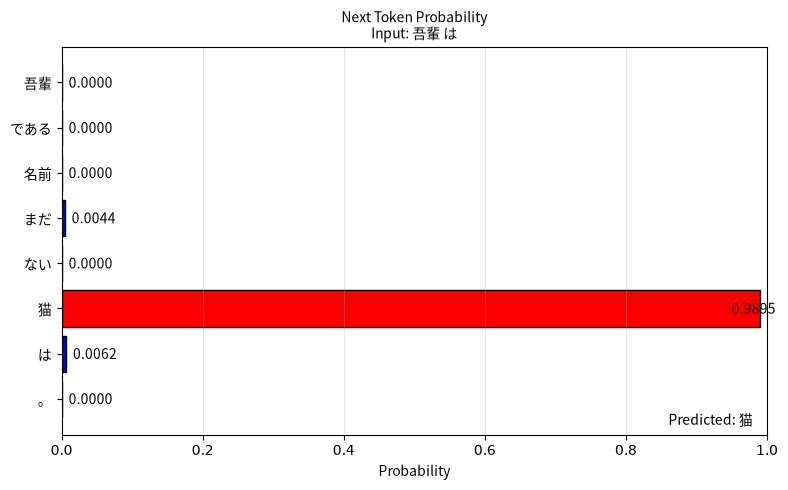


Input     : 吾輩 は
Predicted : 猫
Probability: 0.9895


In [53]:
result = plot_dynamic_next_token_probability(
    model=model,
    text="吾輩　は",
    stoi=stoi,
    vocab=vocab,
    itos=itos
)

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-noto-cjk

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 129 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 1s (100 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1

In [97]:
# ============================================================
# PyVista
# ============================================================
!python3 -m pip install pyvista
!pip install -U ipywidgets jupyterlab_widgets
!pip install trame trame-vtk trame-vuetify
import pyvista as pv
import numpy as np
import pyvista as pv

pv.set_jupyter_backend("trame")
# ------------------------------------------------------------
# Color
# ------------------------------------------------------------

COLORS = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "cyan",
    "magenta",
    "black"
]

# ------------------------------------------------------------
# Plotter
# ------------------------------------------------------------

def create_plotter(
    title="Word Embedding",
    window_size=(1200,900)
):
    """
    PyVista Plotter を作成
    """

    pv.set_plot_theme("document")

    plotter = pv.Plotter(
        window_size=window_size,
        title=title
    )

    plotter.set_background("white")

    # XYZ軸
    plotter.show_axes()

    # 床グリッド
    plotter.show_grid(
        color="gray",
        location="outer"
    )

    # 原点
    origin = pv.Sphere(
        radius=0.01,
        center=(0,0,0)
    )

    plotter.add_mesh(
        origin,
        color="black"
    )

    return plotter

# ============================================================
# Word Embedding
# ============================================================

def draw_word_embedding(
    plotter,
    history,
    vocab=VOCAB
):
    """
    Word Embeddingを3D表示
    """

    last = history[-1]

    emb = last["embedding_weight"].numpy()

    for i, token in enumerate(vocab):

        x, y, z = emb[i]

        #-----------------------------------------
        # 球
        #-----------------------------------------

        sphere = pv.Sphere(
            radius=0.03,
            center=(x, y, z)
        )

        plotter.add_mesh(
            sphere,
            color=COLORS[i]
        )

        #-----------------------------------------
        # ラベル
        #-----------------------------------------

        plotter.add_point_labels(

            np.array([[x, y, z]]),

            [token],

            font_size=18,

            point_size=0,

            shape=None,

            always_visible=True

        )

    return plotter


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [121]:
import torch

state = torch.load(
    "history/030000.pt",
    map_location="cpu",
    weights_only=False
)

print(state.keys())

dict_keys(['token_embedding', 'position_embedding', 'embedding', 'block_output', 'q_raw', 'k_raw', 'v_raw', 'q', 'k', 'v', 'attention', 'context', 'attn_output', 'ffn_fc', 'ffn_gelu', 'ffn_proj', 'ffn_output', 'final_embedding', 'logits', 'probability', 'embedding_weight', 'position_weight', 'LN_F_weight', 'LN_F_bias', 'WQ', 'WK', 'WV', 'WQ_bias', 'WK_bias', 'WV_bias', 'WO', 'WO_bias', 'FFN1', 'FFN1_bias', 'FFN2', 'FFN2_bias', 'LM_head', 'Logits', 'Probability', 'iter', 'loss'])


In [98]:
print(pv.global_theme.jupyter_backend)

trame


In [ ]:
!pip install plotly

In [75]:
%matplotlib notebook

In [ ]:
!pip uninstall matplotlib
!pip install matplotlib==3.9.4
!pip install --upgrade ipympl

In [79]:
Y

NameError: name 'Y' is not defined

In [111]:
history = load_history()

state = history[-1]

for k in sorted(state.keys()):
    print(k)

HISTORY
directory : history
files     : 301
first     : 000000.pt
last      : 030000.pt
FFN1
FFN1_bias
FFN2
FFN2_bias
LM_head
Probability
WK
WK_bias
WO
WO_bias
WQ
WQ_bias
WV
WV_bias
attention
attn_output
block_output
context
embedding
embedding_weight
ffn_fc
ffn_gelu
ffn_output
ffn_proj
final_embedding
iter
k
k_raw
loss
position_embedding
position_weight
q
q_raw
token_embedding
v
v_raw


## Visualize_forward.py

## Visualize_forward.py

In [12]:
# ============================================================
# visualize_forward.py
#
# 教材用
# 学習済みTransformer内部計算表示
#
# historyは使用しない
# ckpt.ptのみ使用
# ============================================================

import os
import pickle
import numpy as np
import torch

from contextlib import nullcontext

#os.chdir("/content/nanoGPT")
import os

os.chdir(os.path.expanduser("~/nanoGPTTutorial/nanoGPT"))

from model import GPTConfig
from model import GPT

# ============================================================
# 設定
# ============================================================

device = "cpu"

out_dir = "out"

checkpoint = os.path.join(
    out_dir,
    "ckpt.pt"
)

# ============================================================
# checkpoint
# ============================================================

ckpt = torch.load(
    checkpoint,
    map_location=device
)

gptconf = GPTConfig(
    **ckpt["model_args"]
)

model = GPT(gptconf)

state_dict = ckpt["model"]

unwanted_prefix = "_orig_mod."

for k, v in list(state_dict.items()):

    if k.startswith(unwanted_prefix):

        state_dict[
            k[len(unwanted_prefix):]
        ] = state_dict.pop(k)

model.load_state_dict(state_dict)

model.eval()

model.to(device)

# ============================================================
# vocabulary
# ============================================================
meta_path = "data/jp/meta.pkl"
#meta_path = os.path.join(
#    ckpt["config"]["dataset"],
#    "meta.pkl"
#)

if not os.path.exists(meta_path):

    meta_path = "data/jp/meta.pkl"

with open(meta_path, "rb") as f:

    meta = pickle.load(f)

stoi = meta["stoi"]

itos = meta["itos"]

vocab = [
    itos[i]
    for i in range(len(itos))
]

print()

print("========================================")
print("Vocabulary")
print("========================================")

for i, token in enumerate(vocab):

    print(
        f"{i:3d} : {token}"
    )
# ============================================================
# 入力文字列 → Token ID
# ============================================================

def encode_input_text(text, stoi):

    tokens = text.strip().split()

    if len(tokens) == 0:
        raise ValueError("入力が空です。")

    unknown = [
        t
        for t in tokens
        if t not in stoi
    ]

    if len(unknown) != 0:

        raise ValueError(
            "語彙に存在しません : "
            + ",".join(unknown)
        )

    ids = [
        stoi[t]
        for t in tokens
    ]

    return tokens, ids
# ============================================================
# 共通
# ============================================================
def get_tensor(vd, key):

    x = vd[key]

    while isinstance(x, list):
        x = x[0]

    while x.ndim >= 2 and x.shape[0] == 1:
        x = x[0]

    return x.detach().cpu()
# ============================================================
# Forward
# ============================================================

def run_forward(
    text
):

    tokens, ids = encode_input_text(
        text,
        stoi
    )

    x = torch.tensor(
        [ids],
        dtype=torch.long,
        device=device
    )

    model.enable_visualization(True)

    with torch.no_grad():

        logits, _ = model(x)

    vd = model.visual_data

    return (
        tokens,
        ids,
        vd
    )


# ============================================================
# Embedding表示
# ============================================================

def show_embedding(
    tokens,
    vd
):

    #emb = vd["token_embedding"][0]
    emb = get_tensor(vd, "token_embedding")

    print()

    print("============================================================")
    print("TOKEN EMBEDDING")
    print("============================================================")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(
            np.round(
                emb[i].numpy(),
                4
            )
        )


# ============================================================
# Position Embedding
# ============================================================

def show_position_embedding(
    tokens,
    vd
):

    pos = vd["position_embedding"]

    print()

    print("============================================================")
    print("POSITION EMBEDDING")
    print("============================================================")

    for i in range(len(tokens)):

        print("----------------------------------------")
        print(f"Position {i}")

        print(
            np.round(
                pos[i].numpy(),
                4
            )
        )


# ============================================================
# Embedding + Position
# ============================================================

def show_embedding_sum(
    tokens,
    vd
):

    #x = vd["embedding"][0]
    x = get_tensor(vd, "embedding")

    print()

    print("============================================================")
    print("EMBEDDING + POSITION")
    print("============================================================")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(
            np.round(
                x[i].numpy(),
                4
            )
        )
# ============================================================
# LayerNorm1
# ============================================================

def show_ln1(tokens, vd):

    print()
    print("============================================================")
    print("LAYER NORM 1")
    print("============================================================")

    #ln = vd["ln1"][0][0]
    ln = get_tensor(vd, "ln1")
    

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            ln[i].numpy(),
            4
        ))


# ============================================================
# WQ
# ============================================================

def show_WQ(vocab, vd):

    print()
    print("============================================================")
    print("WQ")
    print("============================================================")

    print(np.round(
        vd["WQ"].numpy(),
        4
    ))


# ============================================================
# WK
# ============================================================

def show_WK(vocab, vd):

    print()
    print("============================================================")
    print("WK")
    print("============================================================")

    print(np.round(
        vd["WK"].numpy(),
        4
    ))


# ============================================================
# WV
# ============================================================

def show_WV(vocab, vd):

    print()
    print("============================================================")
    print("WV")
    print("============================================================")

    print(np.round(
        vd["WV"].numpy(),
        4
    ))


# ============================================================
# Q
# ============================================================
def show_Q(tokens, vd):

    print()
    print("============================================================")
    print("Q")
    print("============================================================")

    #q = vd["q"][0][0][0]
    q = get_tensor(vd, "q")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(q[i].numpy(),4))

# ============================================================
# K
# ============================================================

def show_K(tokens, vd):

    print()
    print("============================================================")
    print("K")
    print("============================================================")

    #k = vd["k"][0][0][0]
    k = get_tensor(vd, "k")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            k[i].numpy(),
            4
        ))


# ============================================================
# V
# ============================================================

def show_V(tokens, vd):

    print()
    print("============================================================")
    print("V")
    print("============================================================")

    #v = vd["v"][0][0][0]
    v = get_tensor(vd, "v")
    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            v[i].numpy(),
            4
        ))
# ============================================================
# Attention Score
# ============================================================

def show_attention_score(tokens, vd):

    print()
    print("============================================================")
    print("ATTENTION SCORE")
    print("============================================================")

    #score = vd["attention_score"][0][0][0]
    score = get_tensor(vd, "attention_score")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Query Position {i}")
        print(token)

        print(np.round(
            score[i].numpy(),
            4
        ))


# ============================================================
# Masked Score
# ============================================================

def show_masked_score(tokens, vd):

    print()
    print("============================================================")
    print("MASKED SCORE")
    print("============================================================")

    #score = vd["masked_score"][0][0][0]
    score = get_tensor(vd, "masked_score")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Query Position {i}")
        print(token)

        print(np.round(
            score[i].numpy(),
            4
        ))


# ============================================================
# Attention Probability
# ============================================================

def show_attention_probability(tokens, vd):

    print()
    print("============================================================")
    print("ATTENTION PROBABILITY")
    print("============================================================")
    #prob = vd["attention"][0][0][0]
    prob = get_tensor(vd, "attention")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Query Position {i}")
        print(token)

        print(np.round(
            prob[i].numpy(),
            4
        ))


# ============================================================
# Context Vector
# ============================================================

def show_context(tokens, vd):

    print()
    print("============================================================")
    print("CONTEXT")
    print("============================================================")

    #context = vd["context"][0][0][0]
    context = get_tensor(vd, "context")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            context[i].numpy(),
            4
        ))


# ============================================================
# WO Output
# ============================================================
def show_attention_output(tokens, vd):

    print()
    print("============================================================")
    print("WO OUTPUT")
    print("============================================================")

    y = get_tensor(vd, "attn_output")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            y[i].numpy(),
            4
        ))

# ============================================================
# Residual1
# ============================================================

def show_residual1(tokens, vd):

    print()
    print("============================================================")
    print("RESIDUAL 1")
    print("============================================================")

   # r = vd["residual1"][0]
    r = get_tensor(vd, "residual1")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            r[i].numpy(),
            4
        ))
# ============================================================
# LayerNorm2
# ============================================================

def show_ln2(tokens, vd):

    print()
    print("============================================================")
    print("LAYER NORM 2")
    print("============================================================")

    #x = vd["ln2"][0]
    x = get_tensor(vd, "ln2")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            x[i].numpy(),
            4
        ))


# ============================================================
# FFN FC
# ============================================================

def show_ffn_fc(tokens, vd):

    print()
    print("============================================================")
    print("FFN c_fc")
    print("============================================================")

    #x = vd["ffn_fc"][0]
    x = get_tensor(vd, "ffn_fc")
   

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            x[i].numpy(),
            4
        ))


# ============================================================
# GELU
# ============================================================

def show_ffn_gelu(tokens, vd):

    print()
    print("============================================================")
    print("GELU")
    print("============================================================")

    #x = vd["ffn_gelu"][0]
    x = get_tensor(vd, "ffn_gelu")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            x[i].numpy(),
            4
        ))


# ============================================================
# FFN Projection
# ============================================================

def show_ffn_proj(tokens, vd):

    print()
    print("============================================================")
    print("FFN c_proj")
    print("============================================================")

    #x = vd["ffn_proj"][0]
    x = get_tensor(vd, "ffn_proj")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            x[i].numpy(),
            4
        ))


# ============================================================
# Residual2
# ============================================================

def show_residual2(tokens, vd):

    print()
    print("============================================================")
    print("RESIDUAL 2")
    print("============================================================")

    #x = vd["residual2"][0]
    x = get_tensor(vd, "residual2")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            x[i].numpy(),
            4
        ))


# ============================================================
# Final LayerNorm
# ============================================================

def show_final_embedding(tokens, vd):

    print()
    print("============================================================")
    print("FINAL LAYER NORM")
    print("============================================================")

    #x = vd["final_embedding"][0]
    x = get_tensor(vd, "final_embedding")

    for i, token in enumerate(tokens):

        print("----------------------------------------")
        print(f"Position {i}")
        print(token)

        print(np.round(
            x[i].numpy(),
            4
        ))


# ============================================================
# Logits
# ============================================================
def show_logits(vd):

    print()
    print("============================================================")
    print("LOGITS")
    print("============================================================")

    logits = get_tensor(vd, "logits")

    print("shape =", logits.shape)

    # (Position, Vocab) の場合は最後のPositionだけ表示
    if logits.ndim == 2:
        logits = logits[-1]

    for token, value in zip(vocab, logits):

        print(f"{token:6s} {value.item():10.4f}")
        
# ============================================================
# Probability
# ============================================================
def show_probability(vd):

    print()
    print("============================================================")
    print("NEXT TOKEN PROBABILITY")
    print("============================================================")

    prob = get_tensor(vd, "probability")

    print("shape =", prob.shape)

    # (Position, Vocab) → 最後のPositionだけ取り出す
    if prob.ndim == 2:
        prob = prob[-1]

    pred = torch.argmax(prob).item()

    for i, p in enumerate(prob):

        mark = " <===" if i == pred else ""

        print(f"{vocab[i]:6s}  {p.item():8.4f}{mark}")

# ============================================================
# Prediction
# ============================================================

def show_prediction(vd):

    #prob = vd["probability"][0,0]
    prob = get_tensor(vd, "probability")

    pred = torch.argmax(prob).item()

    print()
    print("============================================================")
    print("PREDICTED TOKEN")
    print("============================================================")
    print(vocab[pred])

#tokens, ids, vd = run_forward("吾輩 は 猫")
tokens, ids, vd = run_forward("吾輩")

show_embedding(tokens, vd)
show_position_embedding(tokens, vd)
show_embedding_sum(tokens, vd)

show_ln1(tokens, vd)

show_WQ(vocab, vd)
show_WK(vocab, vd)
show_WV(vocab, vd)

show_Q(tokens, vd)
show_K(tokens, vd)
show_V(tokens, vd)

show_attention_score(tokens, vd)
show_masked_score(tokens, vd)
show_attention_probability(tokens, vd)

show_context(tokens, vd)
show_attention_output(tokens, vd)
show_residual1(tokens, vd)

show_ln2(tokens, vd)
show_ffn_fc(tokens, vd)
show_ffn_gelu(tokens, vd)
show_ffn_proj(tokens, vd)
show_residual2(tokens, vd)

show_final_embedding(tokens, vd)
show_logits(vd)
show_probability(vd)
show_prediction(vd)

number of parameters: 0.00M

Vocabulary
  0 : 吾輩
  1 : である
  2 : 名前
  3 : まだ
  4 : ない
  5 : 猫
  6 : は
  7 : 。

TOKEN EMBEDDING
----------------------------------------
Position 0
吾輩
-0.4244

POSITION EMBEDDING
----------------------------------------
Position 0
[-0.0015  0.042  -0.0384]

EMBEDDING + POSITION
----------------------------------------
Position 0
吾輩
-0.426

LAYER NORM 1
----------------------------------------
Position 0
吾輩
-1.6325

WQ
[[-0.8349  0.5778  0.0537]
 [-0.8981  0.6201  0.0887]
 [ 0.8497 -0.5997 -0.0659]]

WK
[[-0.5613  0.1776  0.5722]
 [-0.555   0.1647  0.5843]
 [ 0.5387 -0.1713 -0.5686]]

WV
[[-0.0963  0.2138 -0.136 ]
 [ 0.1369 -0.2274  0.1132]
 [-0.1406  0.2315 -0.0797]]

Q
----------------------------------------
Position 0
吾輩
1.3172

K
----------------------------------------
Position 0
吾輩
2.0138

V
----------------------------------------
Position 0
吾輩
-0.2646

ATTENTION SCORE
----------------------------------------
Query Position 0
吾輩
4.7961

MASKED SCOR

In [22]:

attn = model.transformer.h[0].attn

n = model.config.n_embd

bias = attn.c_attn.bias.detach().cpu().numpy()

print("Q bias")
print(np.round(bias[:n], 4))

print("K bias")
print(np.round(bias[n:2*n], 4))

print("V bias")
print(np.round(bias[2*n:3*n], 4))
WO = attn.c_proj.weight.detach().cpu().numpy()
bO = attn.c_proj.bias.detach().cpu().numpy()

print("\n============================================================")
print("WO")
print("============================================================")
print(np.round(WO, 4))

print("\n============================================================")
print("WO BIAS")
print("============================================================")
print(np.round(bO, 4))
model.transformer.h[0].ln_2.weight
model.transformer.h[0].ln_2.bias
print("weight")
print(model.transformer.h[0].ln_2.weight.detach().cpu().numpy())

print("bias")
print(model.transformer.h[0].ln_2.bias.detach().cpu().numpy())
w = model.transformer.h[0].mlp.c_fc.weight
b = model.transformer.h[0].mlp.c_fc.bias

print("shape =", w.shape)
print(np.round(w.detach().cpu().numpy(),4))

print("bias")
print(np.round(b.detach().cpu().numpy(),4))

print("============================================================")
print("W_proj")
print("============================================================")

W_proj = model.transformer.h[0].mlp.c_proj.weight.detach().cpu().numpy()
b_proj = model.transformer.h[0].mlp.c_proj.bias.detach().cpu().numpy()

print("shape =", W_proj.shape)
print(np.round(W_proj, 4))

print()
print("============================================================")
print("b_proj")
print("============================================================")
print(np.round(b_proj, 4))

print("weight")
print(model.transformer.ln_f.weight.detach().cpu().numpy())
print("---------------------------------------------------")
print("============================================================")
print("Word Embedding (wte.weight)")
print("============================================================")

wte = model.transformer.wte.weight.detach().cpu().numpy()

print("shape =", wte.shape)
print(np.round(wte, 4))

print()

print("============================================================")
print("LM Head (lm_head.weight)")
print("============================================================")

lm = model.lm_head.weight.detach().cpu().numpy()

print("shape =", lm.shape)
print(np.round(lm, 4))


Q bias
[ 0.177   0.1735 -0.1764]
K bias
[ 0.0016  0.0015 -0.001 ]
V bias
[-0.0127  0.0176 -0.0227]

WO
[[ 0.1769 -0.151   0.124 ]
 [-0.0814  0.0571 -0.0318]
 [-0.3166  0.2648 -0.2342]]

WO BIAS
[ 0.0228 -0.0386  0.0074]
weight
[1.5243064 1.4711516 1.6424588]
bias
[ 0.00255895 -0.01270903  0.03972579]
shape = torch.Size([12, 3])
[[ 0.1517 -0.2014  0.2106]
 [ 0.1661 -0.202   0.185 ]
 [ 0.2161 -0.2212  0.1298]
 [ 0.1106 -0.2042  0.2806]
 [-0.1919  0.1522 -0.0102]
 [ 0.346   0.1025 -0.3175]
 [ 0.3199  0.0816 -0.2652]
 [-0.2299  0.1728 -0.0118]
 [ 0.1382 -0.2029  0.2261]
 [ 0.3174  0.0722 -0.2835]
 [ 0.2864 -0.0826 -0.2112]
 [ 0.1168 -0.196   0.2744]]
bias
[ 0.1181  0.1287  0.186   0.0763  0.2194  0.0299 -0.0213  0.2463  0.1051
 -0.0238  0.1524  0.0757]
W_proj
shape = (3, 12)
[[-0.2392 -0.2209 -0.2238 -0.2466  0.1995 -0.1641 -0.1015  0.2179 -0.2327
  -0.1191 -0.3367 -0.2341]
 [ 0.1703  0.1671  0.1891  0.1547 -0.0087 -0.1675 -0.1093  0.0235  0.1585
  -0.1145  0.0819  0.158 ]
 [-0.0041 -0.014

In [6]:
tokens, ids, vd = run_forward(
    "吾輩 は 猫"
)

In [7]:
print(vd.keys())

dict_keys(['token_embedding', 'position_embedding', 'embedding', 'block_output', 'ln1', 'WQ', 'WK', 'WV', 'bQ', 'bK', 'bV', 'q_raw', 'k_raw', 'v_raw', 'q', 'k', 'v', 'attention_score', 'masked_score', 'attention', 'context', 'attn_output', 'residual1', 'ln2', 'ffn_fc', 'ffn_gelu', 'ffn_proj', 'ffn_output', 'residual2', 'final_embedding', 'logits', 'probability'])
